# Pull Plasma Samples for FH1 Study 

Read in raw data files of plasma samples that has already been bridged. Clean and combine these to produce a file with the common column names across the files. 

## Setting Libraries &  Global Settings

In [1]:
## Load Libraries installed from 'add_R_packages.txt'
library(hise)
library(magrittr)
library(tidyverse)
library(readxl)
library(naniar)
library(visdat)
library(janitor)
library(skimr)
library(ggridges)
library(ggpubr)
library(broom)
library(car)
library(gt)
library(gtExtras)
library(gtsummary)
library(knitr)  
library(logger)
library(OlinkAnalyze)
library(devtools)
suppressPackageStartupMessages(library(ComplexHeatmap))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract()   masks magrittr::extract()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ purrr::set_names() masks magrittr::set_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is 

The following object is masked from ‘package:naniar’:

    n_complete




Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:dplyr’:

    recode




The following object is masked from ‘package:purrr’:

    some




Loading required package: usethis



In [2]:
### Load internal helper function libraries 
### that were custom made for this project
source('../00-utilities/functions/00_functions_data_loading.R')
file.sources <- list.files(
    path = "./ndmmFH1_helper_functions", 
    pattern = "\\.R$", full.names = TRUE
)
file.sources
# Source each R file
invisible(sapply(file.sources, source))

Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose




[1] "./ndmmFH1_helper_functions/data_crud.R" 
[2] "./ndmmFH1_helper_functions/data_manip.R"
[3] "./ndmmFH1_helper_functions/data_vis.R"  
[4] "./ndmmFH1_helper_functions/misc.R"      
[5] "./ndmmFH1_helper_functions/static.R"

In [3]:
logger::log_threshold(DEBUG)
logger::log_appender(logger::appender_stdout)
options(repr.plot.width = 16, repr.plot.height = 10, repr.plot.res = 300)

## Download Olink Bridged Files for FH1 & Healthy Donors

In [4]:
hise.olink.ids <- list("00753770-4803-4947-a290-e7469c410067", 
                       "1a528317-bbf3-45b7-82c9-529577cf0b15", 
                       "55d5d20a-506a-459e-8315-7d66276fb8f9", 
                       "59f5f656-085f-4d0b-a240-68a9eb15e68e", 
                       "65103a13-52de-4f65-89fa-dd03296b4ecb", 
                       "7c2d668a-b851-4087-ba31-408de4ce889c", 
                       "b494cce8-1314-4f6e-9666-42f0c6e1c702",
                       "748f218f-07c9-4303-a500-97b7621f920c" # Latest plasma bridged results Q17140
                      )

Download files to cache folder

In [5]:
# Download files to cache folder
data.handles.bridged.list <- downloadFiles(hise.olink.ids)

INFO [2025-09-05 09:25:29] Downloading files from HISE
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 00753770-4803-4947-a290-e7469c410067
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 1a528317-bbf3-45b7-82c9-529577cf0b15
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 55d5d20a-506a-459e-8315-7d66276fb8f9
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 59f5f656-085f-4d0b-a240-68a9eb15e68e
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 65103a13-52de-4f65-89fa-dd03296b4ecb
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 7c2d668a-b851-4087-ba31-408de4ce889c
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: b494cce8-1314-4f6e-9666-42f0c6e1c702
DEBUG [2025-09-05 09:25:29] Attempting to retrieve the following ids: 748f218f-07c9-4303-a500-97b7621f920c
[1] "downloading fileID 00753770-4803-4947-a290-e7469c410067"
[1] "downloading fileID 1a5

cache/7c2d668a-b851-4087-ba31-408de4ce889c/20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz is the reference for bridging

# Background

The csv files have been put through the qc control as found at aifimmunology/olink-qc-analysis. They have been bridge normalised back to the first batch. Erroneous samples have been removed. 

The bridging process introduces new columns. 
- If there is only an NPX column, that is the correct NPX value (first batch).
- If there are derivatives, NPX_qry, NPX_ref and NPX_bridged - NPX_bridged has the correct value.
- Same as above for LOD

Som columns have been renamed along history and a script has been provided by Okada for adjusting the names correctly. 

The scripts harmonises towards the newer bridged samples. 

**Changes columns in earlier bridged samples to match newer ones**
- `'submission'` to `'submission_qry'`
- `'QC_Warning_2'` to `'QC_Warning_qry'`
- `'PlateID'` to `'PlateID_qry'`
- `'sample.sampleKitGuid'` to `'SampleKitGuid'`
- `'Assay_2'` to `'UniqueAssay'`
- `'ReferenceSubmission'` to `'submission_ref'`
- `'AIFI_Flag'` to `'Manual_QC_Flag'`
- `'AIFI_Flag_Reason'` to `'Manual_QC_Note'`
- `'NPX_reference_batch'` to `'NPX_ref'`

**Changes columns in first sample to match newer bridged samples**
- Extracts a substring from `PlateID` up to the first underscore and assigns it to `submission_qry`.
- Sets `BatchOffset` to `0`.
- Copies `PlateID` to `PlateID_qry`.
- Copies `NPX` to `NPX_bridged`.
- Copies `LOD` to `LOD_bridged`.
- Sets `BridgingDetails` to 'No bridge, reference dataset'.
- Copies `QC_Warning` to `QC_Warning_qry`.
- Applies `format_vartypes` to ensure specific columns are of character type.



# Workflow

Below, each csv file will be cleaned in column structure according to above, columns classed accordingly, and frames stacked to one frame with all data. Other data than pertaining to FH1 and BR1 and BR 2 will be removed. These will then be joined with the clinical data with the kitguid as key. The resulting file will be saved to the project folder. 
Data structure, outlier and missingness analysis will then be done. A new file will be saved if samples are removed based on this. 

1. Column cleaning and harmonisation across files
2. Data structure analysis
3. Data combine -> saved as "Normalised Unabridged Olink Plasma Samples FH1.csv"


### NPX Data Structure

For reference, the original column data structure as advised by Olink is mentioned here. The other columns in the files are are added. 

- **SampleID** `<chr>`: Sample names or IDs.
- **Index** `<int>`: Unique number for each SampleID. It is used to make up for non-unique sample IDs.
- **OlinkID** `<chr>`: Unique ID for each assay assigned by Olink. In case the assay is included in more than one panel, it will have a different OlinkID in each one.
- **UniProt** `<chr>`: UniProt ID.
- **Assay** `<chr>`: Common gene name for the assay.
- **MissingFreq** `<dbl>`: Missing frequency for the OlinkID, i.e., frequency of samples with NPX value below limit of detection (LOD).
- **Panel** `<chr>`: Olink Panel that samples ran on. Read more about Olink Panels here: <https://olink.com/products-services/>.
- **Panel_Version** `<chr>`: Version of the panel. A new panel version might include some different or improved assays.
- **PlateID** `<chr>`: Name of the plate.
- **QC_Warning** `<chr>`: Indication whether the sample passed Olink QC. Read more here: <https://olink.com/faq/how-is-quality-control-of-the-data-performed/>.
- **LOD** `<dbl>`: Limit of detection (LOD) is the minimum level of an individual protein that can be measured. LOD is defined as 3 times the standard deviation over the background.
- **NPX** `<dbl>`: Normalized Protein eXpression, is Olink®’s unit of protein expression level in a log2 scale. The majority of the functions of this package use NPX values for calculations. Read more about NPX here: <https://olink.com/faq/what-is-npx/>.

Load the data from csv files

In [6]:
getFileNames(data.handles.bridged.list)

[1] "/home/workspace/input/4095849279/olink_cohort/00753770-4803-4947-a290-e7469c410067/AIFI-2021-09-04T02:22:24.868949746Z/20211036-Skene_July2021Submission/bridging/20211036_Skene_NPX_2021-08-17_Bridged20210903.csv"          
[2] "/home/workspace/input/4095849279/olink_cohort/1a528317-bbf3-45b7-82c9-529577cf0b15/AIFI-2022-05-31T18:46:21.901486861Z/20211037-Skene_May2021Submission/bridging-results/20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv"
[3] "/home/workspace/input/4095849279/olink_cohort/55d5d20a-506a-459e-8315-7d66276fb8f9/AIFI-2022-06-21T18:36:45.255457305Z/Q-02017_olink_bridged_results.csv"                                                                     
[4] "/home/workspace/input/4095849279/olink_cohort/59f5f656-085f-4d0b-a240-68a9eb15e68e/AIFI-2022-02-19T01:50:28.37728978Z/20212223_olink_bridged_results.csv"                                                                     
[5] "/home/workspace/input/4095849279/FH_MM_Year4/65103a13-52de-4f65-89fa-dd03296b4ecb/Olink/Q-09225_FH-Y4_olink_bridged_results.csv"                                                                                              
[6] "/home/workspace/input/4095849279/olink_cohort/7c2d668a-b851-4087-ba31-408de4ce889c/20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz"                                                                                         
[7] "/home/workspace/input/4095849279/olink_cohort/b494cce8-1314-4f6e-9666-42f0c6e1c702/AIFI-2023-06-23T22:43:24.411227655Z/q-04064/Q-04064_olink_bridged_results.csv"                                                             
[8] "/home/workspace/input/4095849279/FH_MM_Year4/748f218f-07c9-4303-a500-97b7621f920c/Q-17140_olink_bridged_results.csv"

In [7]:
# NOTE this cell might take a long time to run 
data.olink.raw.unclipped <- getFileNames(data.handles.bridged.list) %>%
    {suppressWarnings( #columns_spec for all columns, but each csv less columns than union of all
        readCSVFiles(., #col_types = column_types, 
               col_name = TRUE,
               na = c("", "NA"), 
               quoted_na = TRUE, lazy=FALSE))}

INFO [2025-09-05 09:26:23] Starting to read CSV files.
INFO [2025-09-05 09:26:23] Reading file: /home/workspace/input/4095849279/olink_cohort/00753770-4803-4947-a290-e7469c410067/AIFI-2021-09-04T02:22:24.868949746Z/20211036-Skene_July2021Submission/bridging/20211036_Skene_NPX_2021-08-17_Bridged20210903.csv


Rows: 518144 Columns: 55
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (31): SampleID, OlinkID, UniProt, Assay, Panel, Panel_Lot_Nr, PlateID, ...
dbl  (14): Index, MissingFreq, LOD, NPX, sample.daysSinceFirstVisit, subject...
lgl   (8): sample.bridgingControl, file.batchID, file.panel, file.pool, file...
dttm  (2): lastUpdated, sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


INFO [2025-09-05 09:26:32] Reading file: /home/workspace/input/4095849279/olink_cohort/1a528317-bbf3-45b7-82c9-529577cf0b15/AIFI-2022-05-31T18:46:21.901486861Z/20211037-Skene_May2021Submission/bridging-results/20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv


Rows: 518144 Columns: 55
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (32): SampleID, OlinkID, UniProt, Assay, Panel, Panel_Lot_Nr, PlateID, ...
dbl  (14): Index, MissingFreq, LOD, NPX, sample.daysSinceFirstVisit, subject...
lgl   (7): sample.bridgingControl, file.batchID, file.panel, file.pool, file...
dttm  (2): lastUpdated, sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


INFO [2025-09-05 09:26:40] Reading file: /home/workspace/input/4095849279/olink_cohort/55d5d20a-506a-459e-8315-7d66276fb8f9/AIFI-2022-06-21T18:36:45.255457305Z/Q-02017_olink_bridged_results.csv


...

INFO [2025-09-05 09:26:58] Reading file: /home/workspace/input/4095849279/olink_cohort/b494cce8-1314-4f6e-9666-42f0c6e1c702/AIFI-2023-06-23T22:43:24.411227655Z/q-04064/Q-04064_olink_bridged_results.csv


Rows: 861087 Columns: 41
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (27): SampleID, OlinkID, UniProt, Assay, Panel, Panel_Lot_Nr, PlateID_qr...
dbl (12): Index, MissingFreq, LOD_qry, NPX_qry, Column, NPX_ref, LOD_ref, su...
lgl  (2): Is_plate_control, is_bridge_contol

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


INFO [2025-09-05 09:27:05] Reading file: /home/workspace/input/4095849279/FH_MM_Year4/748f218f-07c9-4303-a500-97b7621f920c/Q-17140_olink_bridged_results.csv


Rows: 663060 Columns: 51
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (32): SampleID, SampleType, WellID, PlateID_qry, DataAnalysisRefID, Olin...
dbl (16): V1, Count, ExtNPX, NPX_qry, PCNormalizedNPX, LOD_qry, PCNormalized...
lgl  (3): Is_plate_control, is_bridge_contol, Manual_QC_Flag

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


INFO [2025-09-05 09:27:13] Completed reading all CSV files.


In [8]:
names(data.olink.raw.unclipped)

[1] "/home/workspace/input/4095849279/olink_cohort/00753770-4803-4947-a290-e7469c410067/AIFI-2021-09-04T02:22:24.868949746Z/20211036-Skene_July2021Submission/bridging/20211036_Skene_NPX_2021-08-17_Bridged20210903.csv"          
[2] "/home/workspace/input/4095849279/olink_cohort/1a528317-bbf3-45b7-82c9-529577cf0b15/AIFI-2022-05-31T18:46:21.901486861Z/20211037-Skene_May2021Submission/bridging-results/20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv"
[3] "/home/workspace/input/4095849279/olink_cohort/55d5d20a-506a-459e-8315-7d66276fb8f9/AIFI-2022-06-21T18:36:45.255457305Z/Q-02017_olink_bridged_results.csv"                                                                     
[4] "/home/workspace/input/4095849279/olink_cohort/59f5f656-085f-4d0b-a240-68a9eb15e68e/AIFI-2022-02-19T01:50:28.37728978Z/20212223_olink_bridged_results.csv"                                                                     
[5] "/home/workspace/input/4095849279/FH_MM_Year4/65103a13-52de-4f65-89fa-dd03296b4ecb/Olink/Q-09225_FH-Y4_olink_bridged_results.csv"                                                                                              
[6] "/home/workspace/input/4095849279/olink_cohort/7c2d668a-b851-4087-ba31-408de4ce889c/20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz"                                                                                         
[7] "/home/workspace/input/4095849279/olink_cohort/b494cce8-1314-4f6e-9666-42f0c6e1c702/AIFI-2023-06-23T22:43:24.411227655Z/q-04064/Q-04064_olink_bridged_results.csv"                                                             
[8] "/home/workspace/input/4095849279/FH_MM_Year4/748f218f-07c9-4303-a500-97b7621f920c/Q-17140_olink_bridged_results.csv"

Trim names to basenames for simplicity

In [9]:
newNames <- lapply(names(data.olink.raw.unclipped), function(x){basename(x)})
newNames

[[1]]
[1] "20211036_Skene_NPX_2021-08-17_Bridged20210903.csv"

[[2]]
[1] "20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv"

[[3]]
[1] "Q-02017_olink_bridged_results.csv"

[[4]]
[1] "20212223_olink_bridged_results.csv"

[[5]]
[1] "Q-09225_FH-Y4_olink_bridged_results.csv"

[[6]]
[1] "20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz"

[[7]]
[1] "Q-04064_olink_bridged_results.csv"

[[8]]
[1] "Q-17140_olink_bridged_results.csv"

In [10]:
names(data.olink.raw.unclipped) <- newNames

## Add sampleKitGuid to latest OLINK batch
- Raw unbridged batch 2 plasma : f2e01435-5de3-43ec-b14e-a003a7426b05
- Bridged batch 2 plasma: 748f218f-07c9-4303-a500-97b7621f920c

In [11]:
library("OlinkQCReport")

Q17140_batch_reformatted_Bridged <- format_olink_metadata(
    hise_fileid="748f218f-07c9-4303-a500-97b7621f920c", #Bridged
    keep_values = c(
      SampleID = "specimen.specimenGuid",
      Cohort = "cohort.cohortGuid",
      Subject = "subject.subjectGuid",
      Sex = "subject.biologicalSex",
      VisitName = "sample.visitName",
      VisitDetails = "sample.visitDetails",
      DaysSinceFirstVisit = "sample.daysSinceFirstVisit",
      SampleKitGuid = "sample.sampleKitGuid"
    ),
    # fileType = "Olink#ProjectStore",
    fileType ='BridgedOlink#ProjectStore'
)


Attaching package: ‘OlinkQCReport’


The following objects are masked _by_ ‘.GlobalEnv’:

    format_olink_metadata, format_specimen_list




257 unique specimen IDs in file
Found 148 specimen IDs that match file
No metadata for 109 specimen IDs in file: [PL05894-001,PL04902-001,PL04711-001,PL04635-001,PL05895-001,PL05898-001,PL04900-001,PL07782-001,PL05870-001,PL04930-001,PL04725-001,PL04895-001,PL05906-001,PL04898-001,PL05900-001,PL05903-001,PL05884-001,PL05882-001,PL04903-001,PL04630-001,PL06517-001,PL05912-001,PL04920-001,PL04722-001,PL05891-001,PL04918-001,PL04716-001,PL02291-001,PL04726-001,PL04727-001,PL05897-001,PL04907-001,PL05878-001,PL04896-001,PL05867-001,PL04904-001,PL07768-001,PL05905-001,PL04720-001,PL04723-001,PL05909-001,PL05896-001,PL05874-001,PL05907-001,PL04894-001,PL04734-001,PL04912-001,PL02296-001,PL05915-001,PL05871-001,PL02304-001,PL04915-001,PL04731-001,PL04732-001,PL04718-001,PL05869-001,PL04913-001,PL06514-001,PL04910-001,PL04909-001,PL05885-001,PL05914-001,PL05892-001,PL04897-001,PL04715-001,PL05901-001,PL04719-001,PL05908-001,PL04906-001,PL04717-001,PL05879-001,PL04926-001,PL04890-001,PL04733-00

We have multiple rows of matching metadata for some sampleIDs. Since each kitID can have several sampleIDs, but each sampleID comes from one kitID, we can filter to unique sampleIDs to facilitate the join of this metadata to the olink data.

In [12]:
Q17140_batch_reformatted_Bridged_distinct <- Q17140_batch_reformatted_Bridged %>% distinct(SampleID, .keep_all = TRUE)
length(unique(Q17140_batch_reformatted_Bridged_distinct$SampleID))
length(unique(data.olink.raw.unclipped[['Q-17140_olink_bridged_results.csv']]$SampleID))

[1] 148

[1] 257

In [13]:
Q17140_batch_reformatted <- dplyr::inner_join(
    data.olink.raw.unclipped[['Q-17140_olink_bridged_results.csv']],
    Q17140_batch_reformatted_Bridged_distinct,
    by="SampleID",
    relationship = "many-to-one")

In [14]:
dim(Q17140_batch_reformatted)


[1] 381840     58

In [15]:
dim(data.olink.raw.unclipped[['Q-17140_olink_bridged_results.csv']])
names(data.olink.raw.unclipped[['Q-17140_olink_bridged_results.csv']])
length(unique(data.olink.raw.unclipped[['Q-17140_olink_bridged_results.csv']]$SampleID))

[1] 663060     51

[1] "V1"                  "SampleID"            "SampleType"         
 [4] "WellID"              "PlateID_qry"         "DataAnalysisRefID"  
 [7] "OlinkID"             "UniProt"             "Assay"              
[10] "AssayType"           "Panel"               "Block"              
[13] "Count"               "ExtNPX"              "NPX_qry"            
[16] "Normalization"       "PCNormalizedNPX"     "Assay_Warning"      
[19] "QC_Warning_qry"      "ExploreVersion"      "LOD_qry"            
[22] "PCNormalizedLOD"     "Index"               "Well"               
[25] "Is_plate_control"    "Row"                 "Column"             
[28] "Dilution"            "DilutionGroup"       "AssayLabel"         
[31] "UniqueAssay"         "PlateMap"            "UniqueSampleID"     
[34] "is_bridge_contol"    "submission_qry"      "Manual_QC_Flag"     
[37] "Manual_QC_Note"      "SampleID_ref"        "SampleID_query"     
[40] "sample_origin"       "NPX_ref"             "LOD_ref"            
[43] "QC_Warning_ref"      "PlateID_ref"         "submission_ref"     
[46] "SampleWarningBridge" "N_Bridge"            "BatchOffset"        
[49] "NPX_bridged"         "LOD_bridged"         "BridgingDetails"

[1] 257

In [16]:
head(Q17140_batch_reformatted)

V1,SampleID,SampleType,WellID,PlateID_qry,DataAnalysisRefID,OlinkID,UniProt,Assay,AssayType,⋯,NPX_bridged,LOD_bridged,BridgingDetails,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,PL06440-001,SAMPLE,A1,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,0.57770310,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH1,FH1014,Male,Flu Year 2 Day 90,N/A - Flu-Series Timepoint Only,1008,KT06440
2,PL05118-001,SAMPLE,A2,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,4.21367715,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH2,FH2008,Female,Other - Non-Flu,MM CD38 6 months,324,KT05118
4,PL04808-002,SAMPLE,A4,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,1.14504973,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH2,FH2004,Female,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,342,KT04808
6,PL05708-001-002,SAMPLE,A6,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,-0.08742942,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",BIOIVT,93508,,,,,KT05708
10,PL05725-001-002,SAMPLE,B1,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,-2.13891103,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",BIOIVT,56967,,,,,KT05725
11,PL02759-004,SAMPLE,B2,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,4.72297142,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH2,FH2008,Female,Other - Non-Flu,MM CD38 Pre-treatment,9,KT02759


Finally replace this Olink file with the appended metadata in the list

In [17]:
data.olink.raw.unclipped[['Q-17140_olink_bridged_results.csv']] <- Q17140_batch_reformatted

# Add metadata from columns

Look at column presence across files in the raw data. 

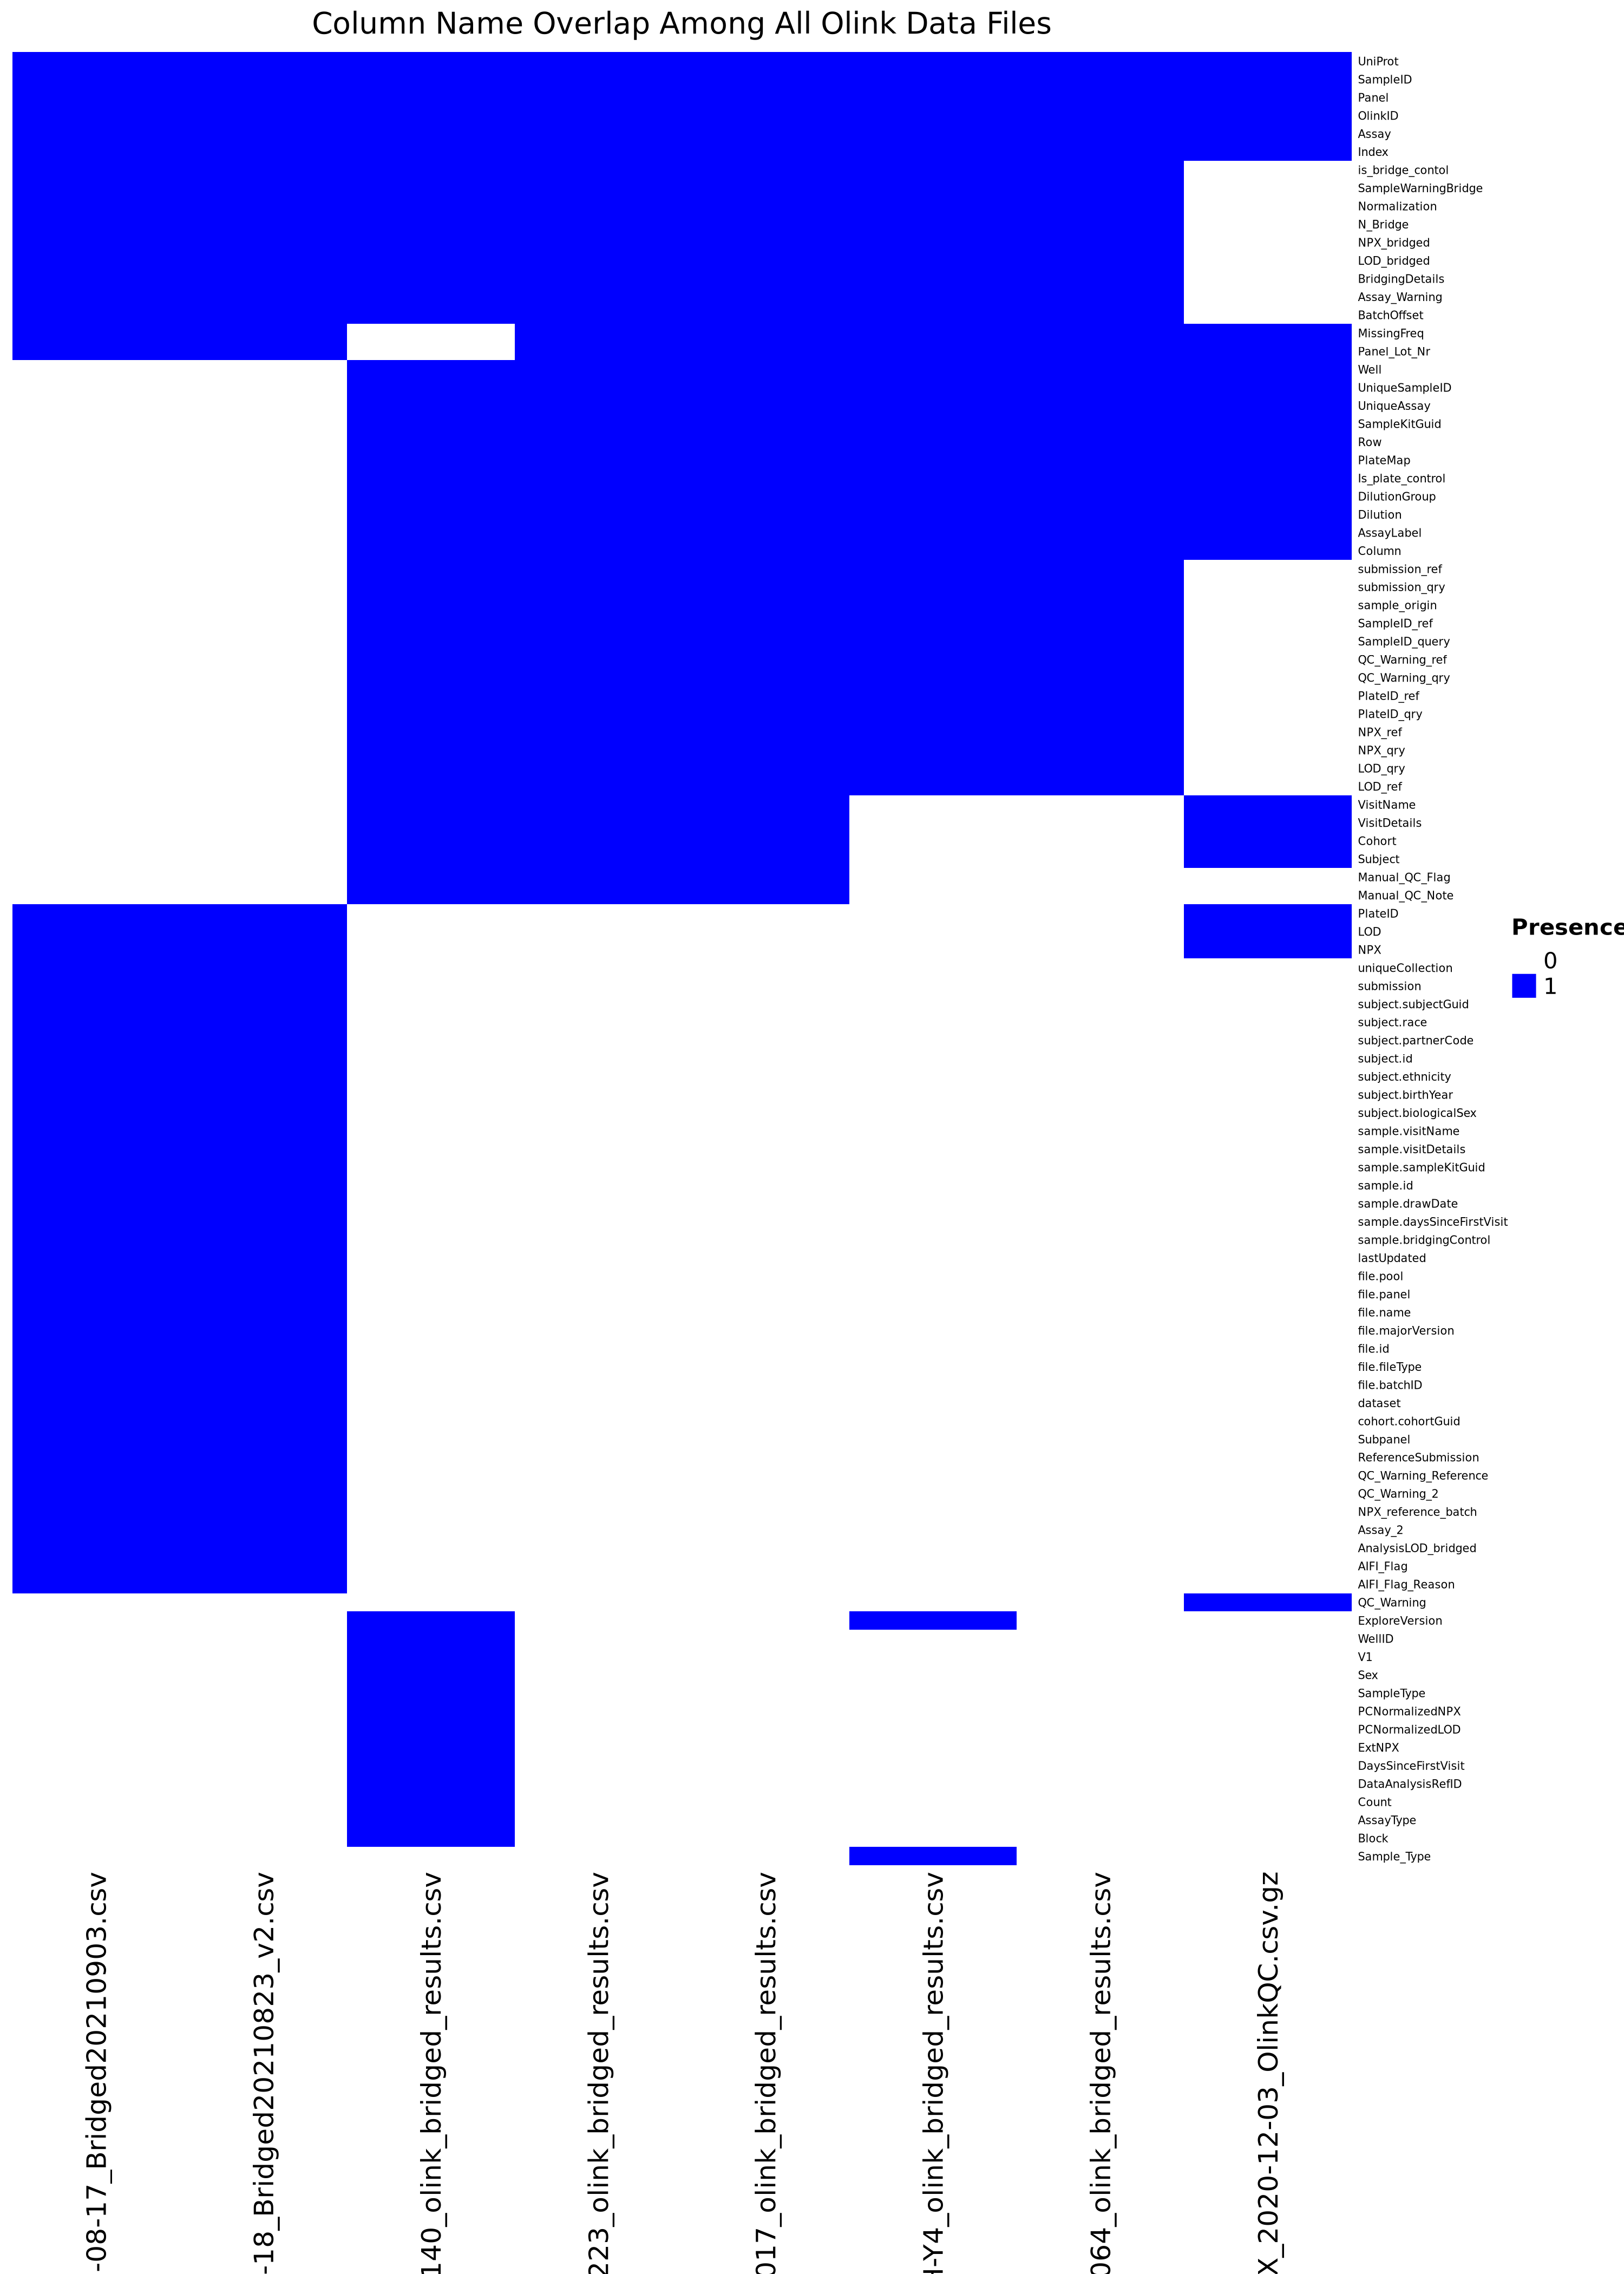

In [18]:
options(repr.plot.width = 10, repr.plot.height = 14)
plot_column_presence_heatmap(data.olink.raw.unclipped, transpose=T, row_names_gp = gpar(fontsize = 5), column_title="Column Name Overlap Among All Olink Data Files")

Reformat according to scripts from Okada

In [19]:
reformat_old <- function(df){
    rename_list <- list('submission' = 'submission_qry', 
                        'QC_Warning_2' = 'QC_Warning_qry',
                        'PlateID'='PlateID_qry',
                        'sample.sampleKitGuid' = 'SampleKitGuid',
                        'Assay_2'='UniqueAssay',
                        'ReferenceSubmission'='submission_ref',
                        'AIFI_Flag'= 'Manual_QC_Flag',
                        'AIFI_Flag_Reason'='Manual_QC_Note',
                        'NPX_reference_batch'='NPX_ref'
                       )
    for (i in seq_along(rename_list)){
        nm <- names(rename_list)[i]
        if(nm %in% names(df)){
            names(df)[which(names(df) == nm)] <- rename_list[[nm]]
        }
    }
    
    df <- format_vartypes(df)
    
    return(df)
}

fmt_qc_to_bridge <- function(qc_df){
    qc_df$submission_qry <- gsub("_.*","", qc_df$PlateID)
    qc_df$BatchOffset <- 0
    qc_df$PlateID_qry <- qc_df$PlateID
    qc_df$NPX_bridged <- qc_df$NPX
    qc_df$LOD_bridged <- qc_df$LOD
    qc_df$BridgingDetails <- 'No bridge, reference dataset'
    qc_df$QC_Warning_qry <- qc_df$QC_Warning
    qc_df <- format_vartypes(qc_df)
    
    return(qc_df)
}

format_vartypes <- function(df){
    df$submission_qry <- as.character(df$submission_qry)
#    df$submission_ref <- as.character(df$submission_ref) #seem to not exist in qc sample 
    return(df)
    
}

file_list <- list(
  old_bridged = c(
    "20211036_Skene_NPX_2021-08-17_Bridged20210903.csv", 
    "20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv"
  ),
  new_bridged = c(
    "Q-02017_olink_bridged_results.csv", 
    "20212223_olink_bridged_results.csv", 
    "Q-09225_FH-Y4_olink_bridged_results.csv",
    "Q-04064_olink_bridged_results.csv",
    "Q-17140_olink_bridged_results.csv"
  ),
  QC_sample = c("20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz")
)


data.olink.raw.okada_reformat <- data.olink.raw.unclipped %>% map2(basename(names(data.olink.raw.unclipped)), \(df, filename) {
  logger::log_debug("checking to rename file {filename}")
  if(filename %in% file_list[["old_bridged"]]) {
    logger::log_info("changing names in old bridged sample {filename}")
    df <- reformat_old(df)
    return(df)
  }
  
  if(filename %in% file_list[["QC_sample"]]) {
    logger::log_info("changing names in qc sample {filename}")
    df <- fmt_qc_to_bridge(df)
    return(df)
  }
  stopifnot(filename %in% file_list[["new_bridged"]])
  return(df)
})



DEBUG [2025-09-05 09:27:35] checking to rename file 20211036_Skene_NPX_2021-08-17_Bridged20210903.csv
INFO [2025-09-05 09:27:35] changing names in old bridged sample 20211036_Skene_NPX_2021-08-17_Bridged20210903.csv
DEBUG [2025-09-05 09:27:35] checking to rename file 20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv
INFO [2025-09-05 09:27:35] changing names in old bridged sample 20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv
DEBUG [2025-09-05 09:27:35] checking to rename file Q-02017_olink_bridged_results.csv
DEBUG [2025-09-05 09:27:35] checking to rename file 20212223_olink_bridged_results.csv
DEBUG [2025-09-05 09:27:35] checking to rename file Q-09225_FH-Y4_olink_bridged_results.csv
DEBUG [2025-09-05 09:27:35] checking to rename file 20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz
INFO [2025-09-05 09:27:35] changing names in qc sample 20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz
DEBUG [2025-09-05 09:27:35] checking to rename file Q-04064_olink_bridged_results.csv
DEBU

Look at column presence after Okada's reformat scripts has been applied

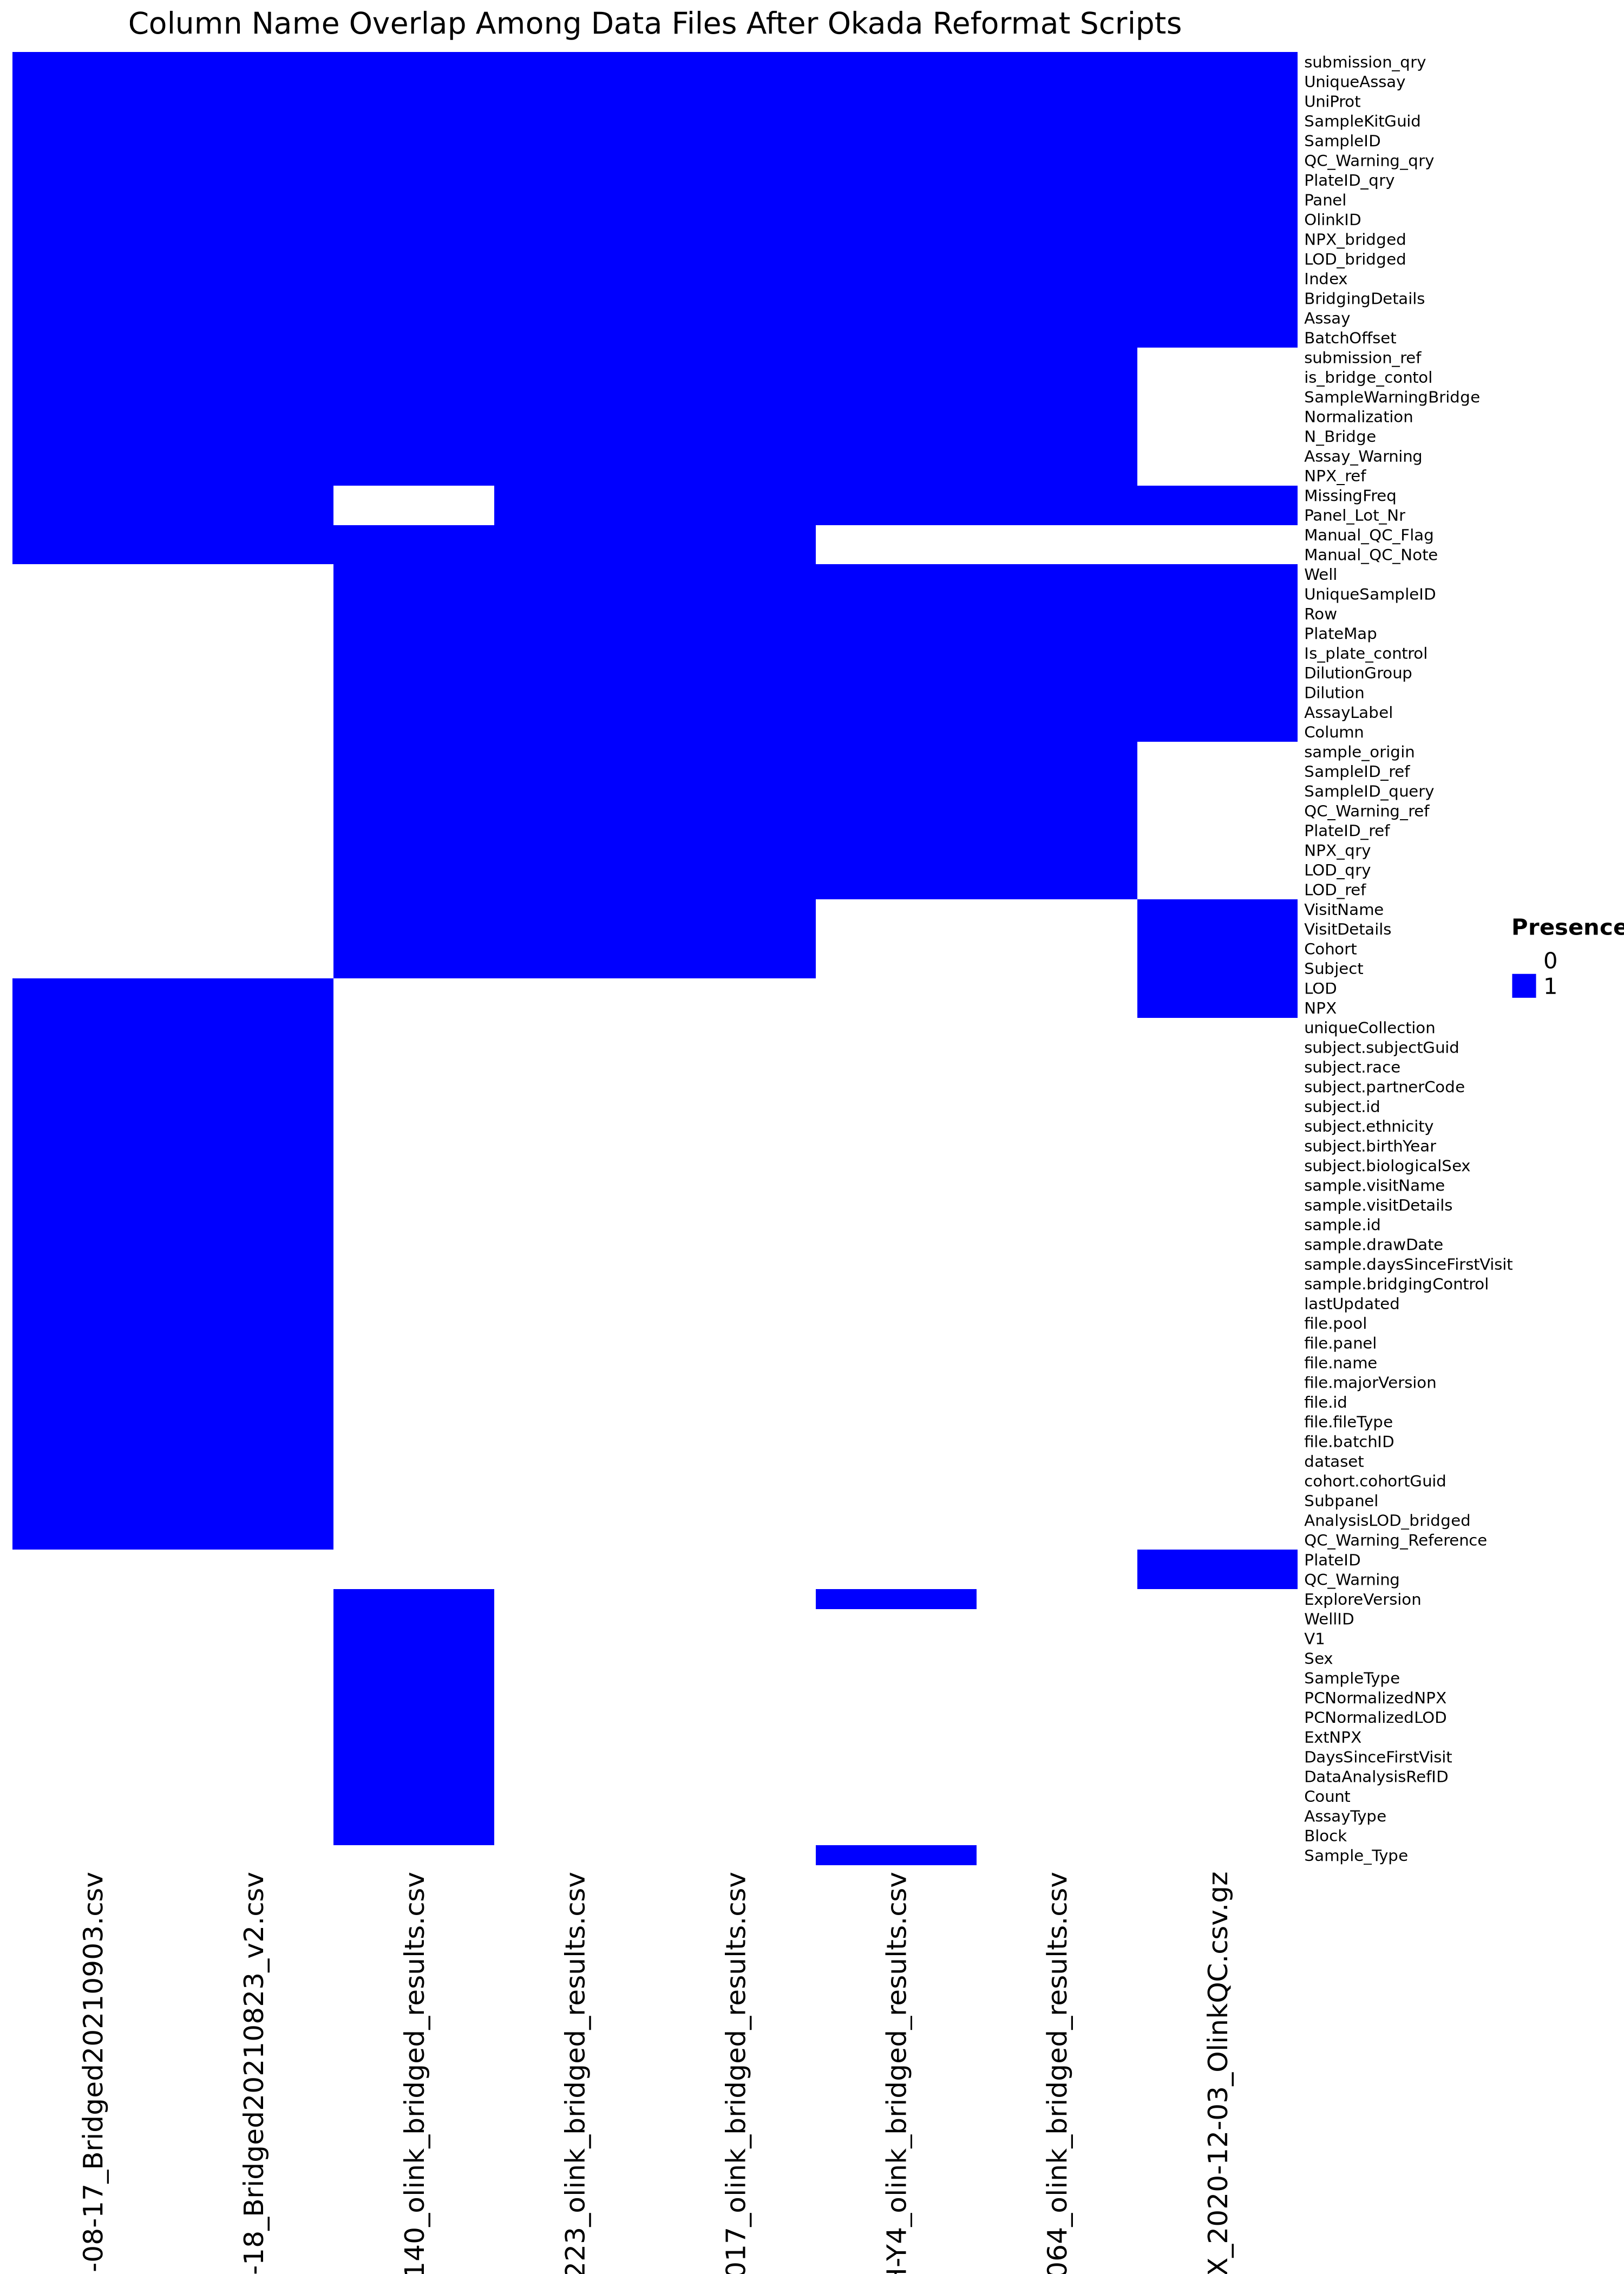

In [20]:
plot_column_presence_heatmap(data.olink.raw.okada_reformat, transpose=T, row_names_gp = gpar(fontsize = 7), column_title="Column Name Overlap Among Data Files After Okada Reformat Scripts")

It can be seen from the table above that there seem to be no column in the FH-Y4 and Q-0464 file that have any column with identifiers for the cohorts in it. 

### Column Names Across All Olink Data Files

The heatmap shows columns (y-axis) per file (x-axis). The column names common to all files after Okada's reformatting scripts has been applied are,
- UniqueAssay
- Uniprot
- sampleKitGuid
- SampleID
- Panel_Lot_Nr
- PlateID_qry
- Panel
- OlinkID
- NPX_bridged
- MissingFreq
- LOD_bridged
- Assay
- Index
- BridgingDetails
- BatchOffset

These columns will be kept and all others removed. Postfix '_qry' and _bridged' will be removed as they have outdone their purpose. The filename will be added as a column for tracing later as well as a batch ID which is just numeric and shorter but serves the same purpose. 
The data will then be combined to one data set. 


Rename and remove columns according to the column mapping. In the column mapping, names assigned to themselves will be kept as is, and names assigned to a new name will change to that name. If that name already exists, the existing new name will be removed first. Names assigned to NULL will be deleted. Then add columns for tracing to filename and batch indicator. 

In [21]:
names(data.olink.raw.okada_reformat)

[1] "20211036_Skene_NPX_2021-08-17_Bridged20210903.csv"   
[2] "20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv"
[3] "Q-02017_olink_bridged_results.csv"                   
[4] "20212223_olink_bridged_results.csv"                  
[5] "Q-09225_FH-Y4_olink_bridged_results.csv"             
[6] "20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz"   
[7] "Q-04064_olink_bridged_results.csv"                   
[8] "Q-17140_olink_bridged_results.csv"

In [22]:
column_mapping <- list(
  UniqueAssay = "UniqueAssay",
  UniProt = "UniProt",
  SampleKitGuid = "sampleKitGuid",
  SampleID = "SampleID",
  Panel_Lot_Nr = "Panel_Lot_Nr",
  PlateID_qry = "PlateID",
  Panel = "Panel",
  OlinkID = "OlinkID",
  NPX_bridged = "NPX",
  MissingFreq = "MissingFreq",
  LOD_bridged = "LOD",
  Assay = "Assay",
  Index = "Index",
  BridgingDetails = "BridgingDetails",
  BatchOffset = "BatchOffset",
  #keep some columns present in all but the first (qc) files
  SampleWarningBridge = "SampleWarningBridge",
  Normalization = "Normalization",
  submission_ref = "submission_ref",
  N_Bridge = "N_Bridge",
  Assay_Warning = "Assay_Warning"
)

filename.batchid.mapping <- list(
  "20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz" = 1,
  "20211037_Skene_NPX_2021-06-18_Bridged20210823_v2.csv" = 2,
  "20211036_Skene_NPX_2021-08-17_Bridged20210903.csv" = 3,
  "Q-02017_olink_bridged_results.csv" = 4,
  "Q-09225_FH-Y4_olink_bridged_results.csv" = 5,
  "Q-04064_olink_bridged_results.csv" = 6,
  "20212223_olink_bridged_results.csv" = 7,
  "Q-17140_olink_bridged_results.csv" = 8  
)

# Add columns to first file (QC) that are common to all other files. 
data.olink.raw.okada_reformat$`20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz` <- 
  mutate(data.olink.raw.okada_reformat$`20201752_Skene_1820_NPX_2020-12-03_OlinkQC.csv.gz`,
          SampleWarningBridge = "reference",
          Normalization = "reference",
          submission_ref = "reference",
          N_Bridge = "reference",
          Assay_Warning = "reference")

data.olink.clipped.renamed <- data.olink.raw.okada_reformat %>%
  map(column_map, column_mapping, delete.missing = T)

data.olink.clipped.renamed <- map2(data.olink.clipped.renamed, basename(names(data.olink.clipped.renamed)), \(df, filename) {
  logger::log_debug("filename is: {filename}")
  logger::log_info("Adding filename {filename} and BatchID {filename.batchid.mapping[[filename]]}")
  mutate(df, filename = filename, BatchID = filename.batchid.mapping[[{{filename}}]])
})

INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: QC_Warning_qry
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: LOD
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: NPX
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: lastUpdated
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: sample.id
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: sample.bridgingControl
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: sample.visitName
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: sample.visitDetails
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: sample.drawDate
INFO [2025-09-05 09:27:39] Added column for deletion due to delete.missing = T: sample.daysSinceFirstVisit
INFO [2025-09-05 09:27:39] Added column for deletion

In [23]:
head(data.olink.raw.okada_reformat$`Q-17140_olink_bridged_results.csv`)

V1,SampleID,SampleType,WellID,PlateID_qry,DataAnalysisRefID,OlinkID,UniProt,Assay,AssayType,⋯,NPX_bridged,LOD_bridged,BridgingDetails,Cohort,Subject,Sex,VisitName,VisitDetails,DaysSinceFirstVisit,SampleKitGuid
<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,PL06440-001,SAMPLE,A1,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,0.57770310,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH1,FH1014,Male,Flu Year 2 Day 90,N/A - Flu-Series Timepoint Only,1008,KT06440
2,PL05118-001,SAMPLE,A2,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,4.21367715,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH2,FH2008,Female,Other - Non-Flu,MM CD38 6 months,324,KT05118
4,PL04808-002,SAMPLE,A4,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,1.14504973,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH2,FH2004,Female,Flu Year 1 Day 90,N/A - Flu-Series Timepoint Only,342,KT04808
6,PL05708-001-002,SAMPLE,A6,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,-0.08742942,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",BIOIVT,93508,,,,,KT05708
10,PL05725-001-002,SAMPLE,B1,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,-2.13891103,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",BIOIVT,56967,,,,,KT05725
11,PL02759-004,SAMPLE,B2,Q-17140_SS240324,E70006,OID20049,P16860,NPPB,assay,⋯,4.72297142,1.515987,"Bridged to submission 20201752 by median offset, warned samples excluded on per-assay basis",FH2,FH2008,Female,Other - Non-Flu,MM CD38 Pre-treatment,9,KT02759


In [24]:
sort(colnames(data.olink.raw.okada_reformat$`Q-17140_olink_bridged_results.csv`))

[1] "Assay"               "AssayLabel"          "AssayType"          
 [4] "Assay_Warning"       "BatchOffset"         "Block"              
 [7] "BridgingDetails"     "Cohort"              "Column"             
[10] "Count"               "DataAnalysisRefID"   "DaysSinceFirstVisit"
[13] "Dilution"            "DilutionGroup"       "ExploreVersion"     
[16] "ExtNPX"              "Index"               "Is_plate_control"   
[19] "LOD_bridged"         "LOD_qry"             "LOD_ref"            
[22] "Manual_QC_Flag"      "Manual_QC_Note"      "NPX_bridged"        
[25] "NPX_qry"             "NPX_ref"             "N_Bridge"           
[28] "Normalization"       "OlinkID"             "PCNormalizedLOD"    
[31] "PCNormalizedNPX"     "Panel"               "PlateID_qry"        
[34] "PlateID_ref"         "PlateMap"            "QC_Warning_qry"     
[37] "QC_Warning_ref"      "Row"                 "SampleID"           
[40] "SampleID_query"      "SampleID_ref"        "SampleKitGuid"      
[43] "SampleType"          "SampleWarningBridge" "Sex"                
[46] "Subject"             "UniProt"             "UniqueAssay"        
[49] "UniqueSampleID"      "V1"                  "VisitDetails"       
[52] "VisitName"           "Well"                "WellID"             
[55] "is_bridge_contol"    "sample_origin"       "submission_qry"     
[58] "submission_ref"

In [25]:
sort(colnames(data.olink.clipped.renamed$`Q-17140_olink_bridged_results.csv`))

[1] "Assay"               "Assay_Warning"       "BatchID"            
 [4] "BatchOffset"         "BridgingDetails"     "Index"              
 [7] "LOD"                 "NPX"                 "N_Bridge"           
[10] "Normalization"       "OlinkID"             "Panel"              
[13] "PlateID"             "SampleID"            "SampleWarningBridge"
[16] "UniProt"             "UniqueAssay"         "filename"           
[19] "sampleKitGuid"       "submission_ref"

MissingFreq and Panel_Lot_Nr not provided by latest OLink, ignore these

In [26]:
# Set type of common cut columns
library(dplyr)

data.olink.clipped.renamed <- data.olink.clipped.renamed %>%
  map(
  ~mutate(.x,
    SampleID = as.factor(SampleID),
    Index = as.factor(Index),
    OlinkID = as.factor(OlinkID),
    UniProt = as.factor(UniProt),
    Assay = as.factor(Assay),
    # MissingFreq = as.numeric(MissingFreq),
    Panel = as.factor(Panel),
    # Panel_Lot_Nr = as.factor(Panel_Lot_Nr),
    PlateID = as.factor(PlateID),
    Normalization = as.factor(Normalization),
    Assay_Warning = as.factor(Assay_Warning),
    sampleKitGuid = as.factor(sampleKitGuid),
    UniqueAssay = as.factor(UniqueAssay),
    N_Bridge = as.factor(N_Bridge),
    BatchOffset = as.factor(BatchOffset),
    submission_ref = as.factor(submission_ref),
    NPX = as.numeric(NPX),
    LOD = as.numeric(LOD),
    SampleWarningBridge = as.factor(SampleWarningBridge),
    BridgingDetails = as.factor(BridgingDetails),
    filename = as.factor(filename),
    BatchID = as.factor(BatchID)
    # Add more columns as needed
  )
)


Check that all files have common column names.

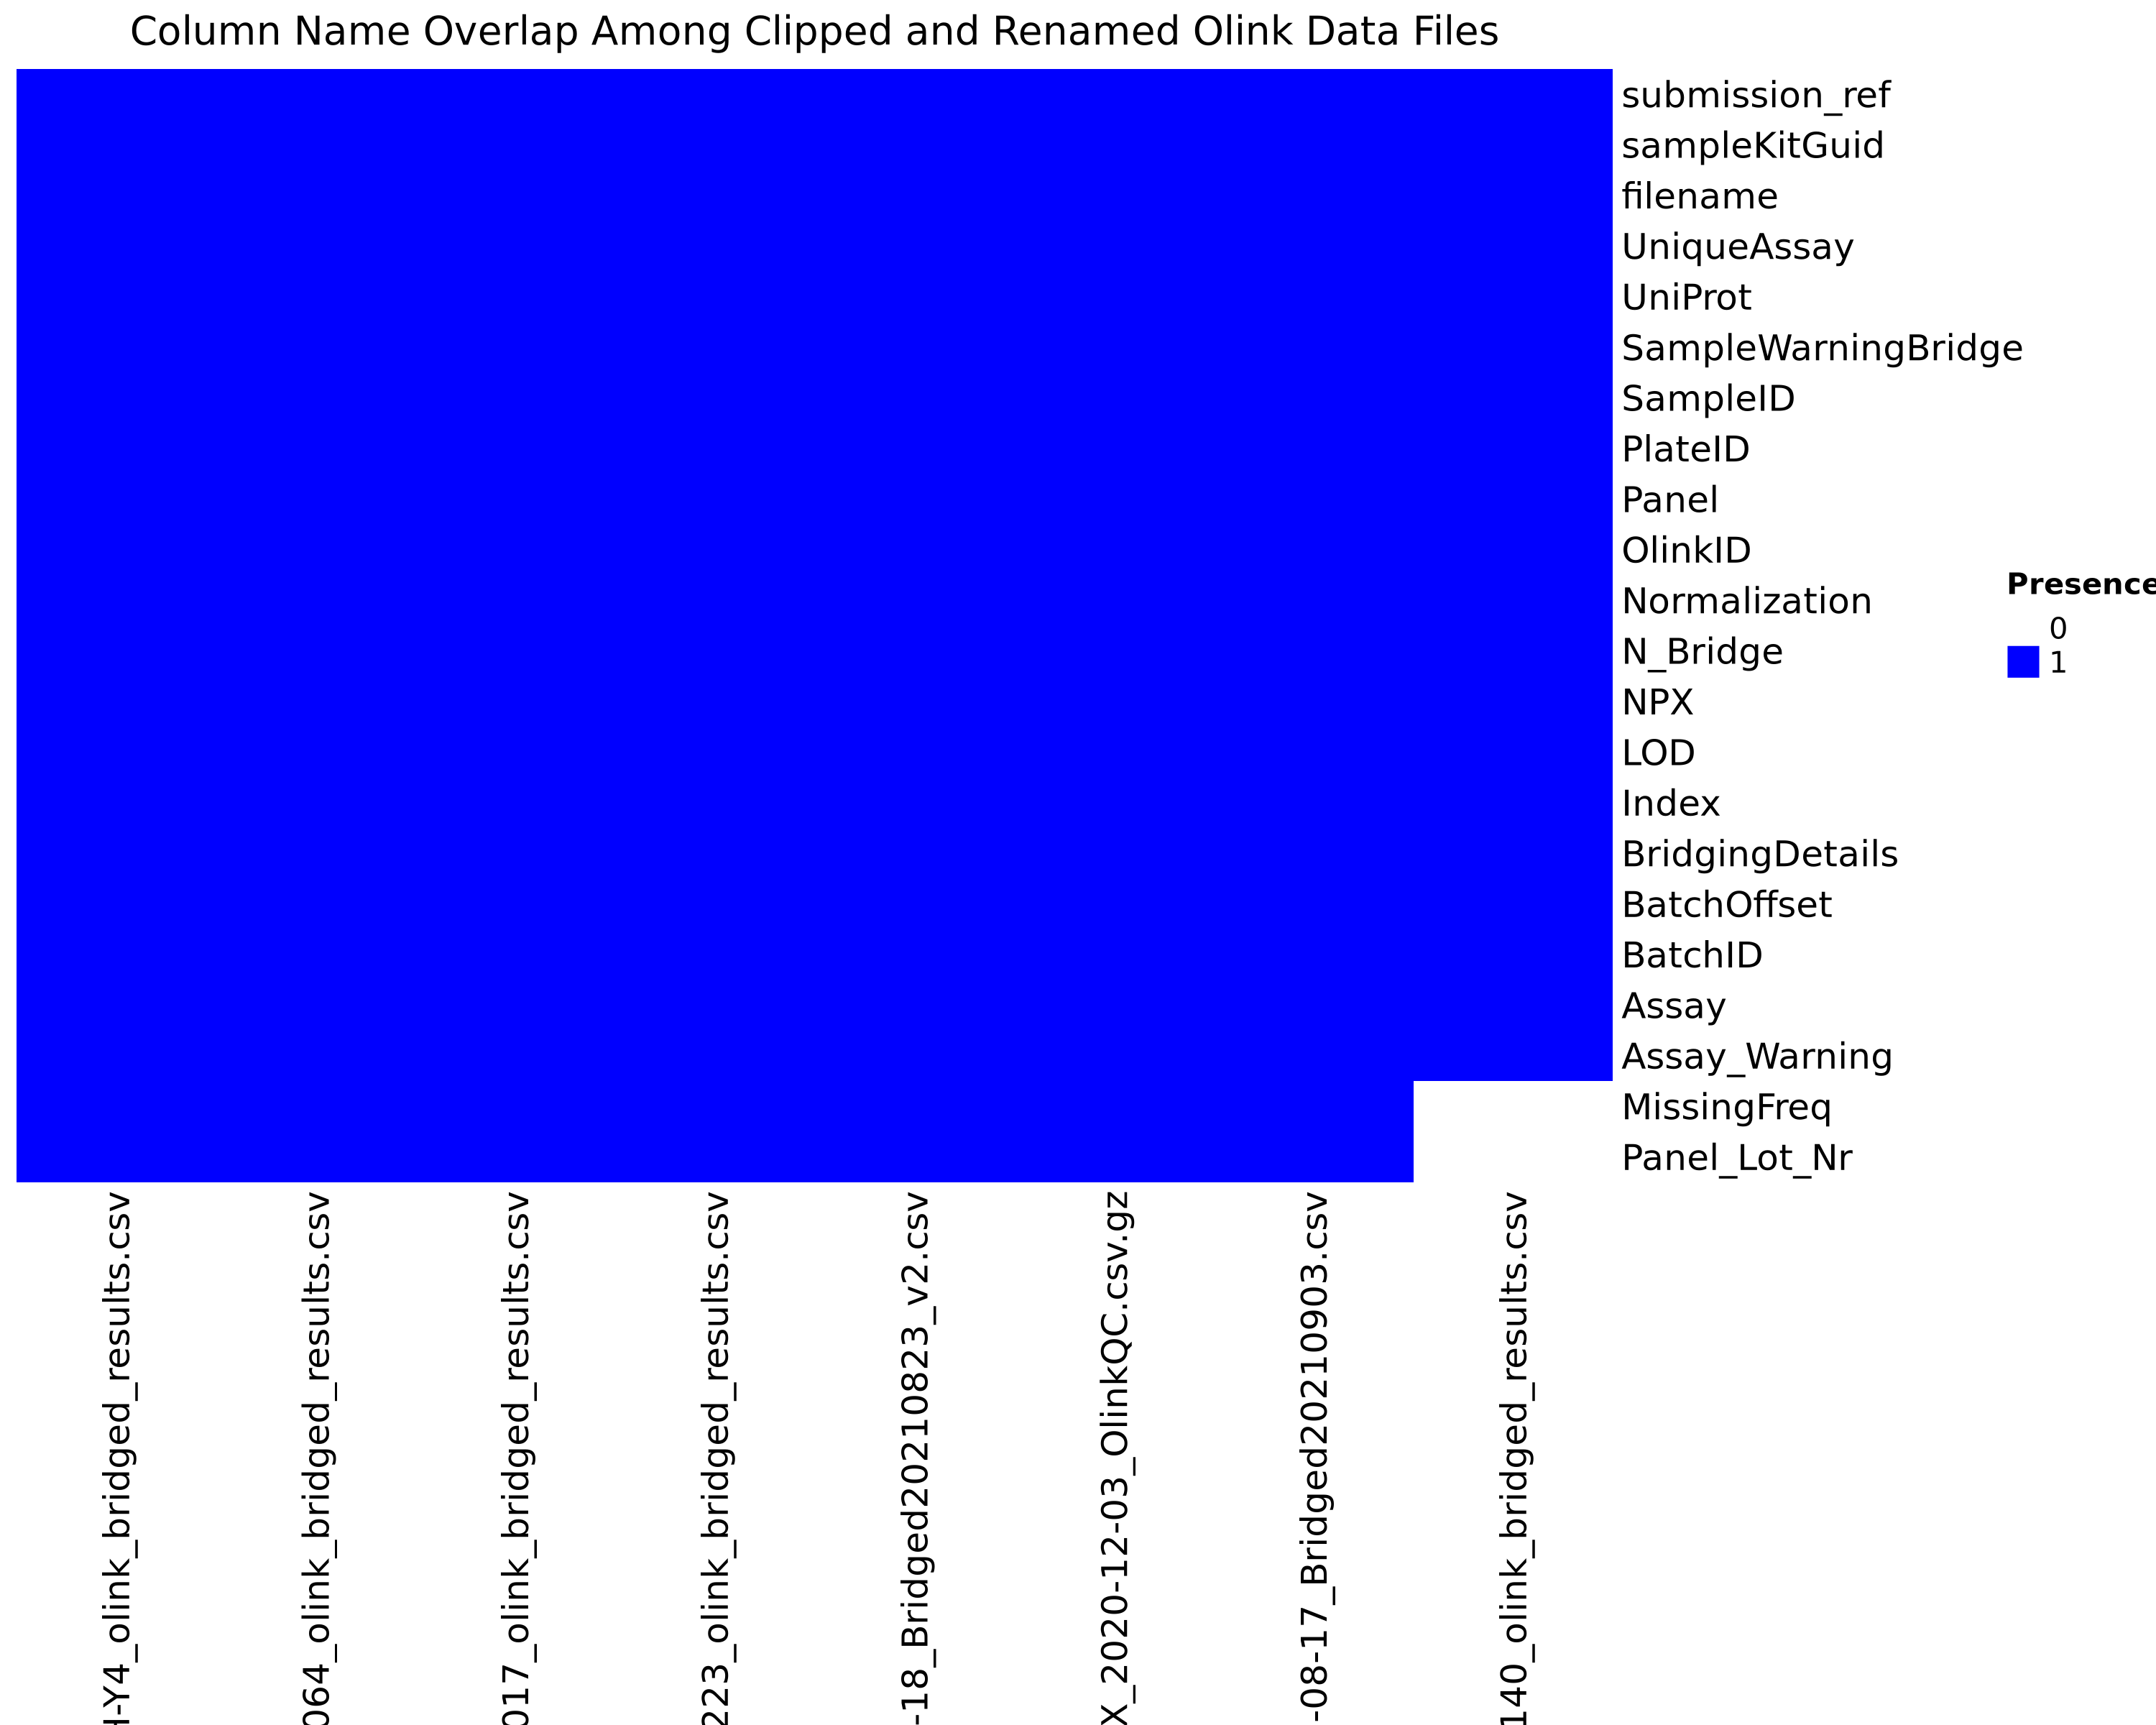

In [27]:
options(repr.plot.width = 10, repr.plot.height = 8)
plot_column_presence_heatmap(data.olink.clipped.renamed, transpose=T, row_names_gp = gpar(fontsize = 12), column_title="Column Name Overlap Among Clipped and Renamed Olink Data Files")

### The second batch of Q-17140 Plasma OLINK is missing:
* MissingFreq 
* Panel_Lot_Nr 
* sampleKitGuid # 1/2025 CORRECTED 

## Check if cohort or subject identifiers is available across all files

In [28]:
#data.olink.raw.okada_reformat %>% map(~head(select(.x, any_of(c("Cohort", "Subject", "cohort.cohortGuid", "subject.subjectGuid", "subject.id", "sample.id", "sample_origin")))))
has_cohorts <- data.olink.raw.okada_reformat %>% 
#  map2(basename(names(data.olink.raw.okada_reformat)), \(df, filename) {mutate(df, file = filename)}) %>%
  map(~select(.x, -c(Assay, UniProt, UniqueAssay))) %>%
  map(~summarise(.x, across(everything(), \(x) {any(grepl("fh1|br1|br2", x, ignore.case = T))}))) %>% 
  map(~select(.x, where(~ all(.x == TRUE)))) %>%
  bind_rows %>%
  add_column(filename = basename(names(data.olink.raw.okada_reformat)), .before=0, ) %>%
  select(-AssayLabel)


gt(has_cohorts) %>% 
  tab_header("Columns with \"FH1|BR1|BR2\" (case insensitive) in them across all plasma olink files") %>% 
  sub_missing() %>% 
  gt:::as.tags.gt_tbl()

Shiny tags cannot be represented in plain text (need html)

## Assay Name Check

Over time, Olinked changed the name of their assays.  
This means that certain OlinkIDs can have more than one associated Assay across all files.


[1] "SampleID"            "Index"               "OlinkID"            
 [4] "UniProt"             "Assay"               "Panel"              
 [7] "PlateID"             "Normalization"       "Assay_Warning"      
[10] "sampleKitGuid"       "UniqueAssay"         "N_Bridge"           
[13] "BatchOffset"         "submission_ref"      "NPX"                
[16] "LOD"                 "SampleWarningBridge" "BridgingDetails"    
[19] "filename"            "BatchID"

DEBUG [2025-09-05 09:29:00] y.axis: ID, x.axis: file, value: value.
INFO [2025-09-05 09:29:00] Found common column: SampleID
INFO [2025-09-05 09:29:00] Found common column: Index
INFO [2025-09-05 09:29:00] Found common column: OlinkID
INFO [2025-09-05 09:29:00] Found common column: UniProt
INFO [2025-09-05 09:29:00] Found common column: Assay
INFO [2025-09-05 09:29:00] Found common column: Panel
INFO [2025-09-05 09:29:00] Found common column: PlateID
INFO [2025-09-05 09:29:00] Found common column: Normalization
INFO [2025-09-05 09:29:00] Found common column: Assay_Warning
INFO [2025-09-05 09:29:00] Found common column: sampleKitGuid
INFO [2025-09-05 09:29:00] Found common column: UniqueAssay
INFO [2025-09-05 09:29:00] Found common column: N_Bridge
INFO [2025-09-05 09:29:00] Found common column: BatchOffset
INFO [2025-09-05 09:29:00] Found common column: submission_ref
INFO [2025-09-05 09:29:00] Found common column: NPX
INFO [2025-09-05 09:29:00] Found common column: LOD
INFO [2025-09-0

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(y.axis)

  # Now:
  data %>% select(all_of(y.axis))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(x.axis)

  # Now:
  data %>% select(all_of(x.axis))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


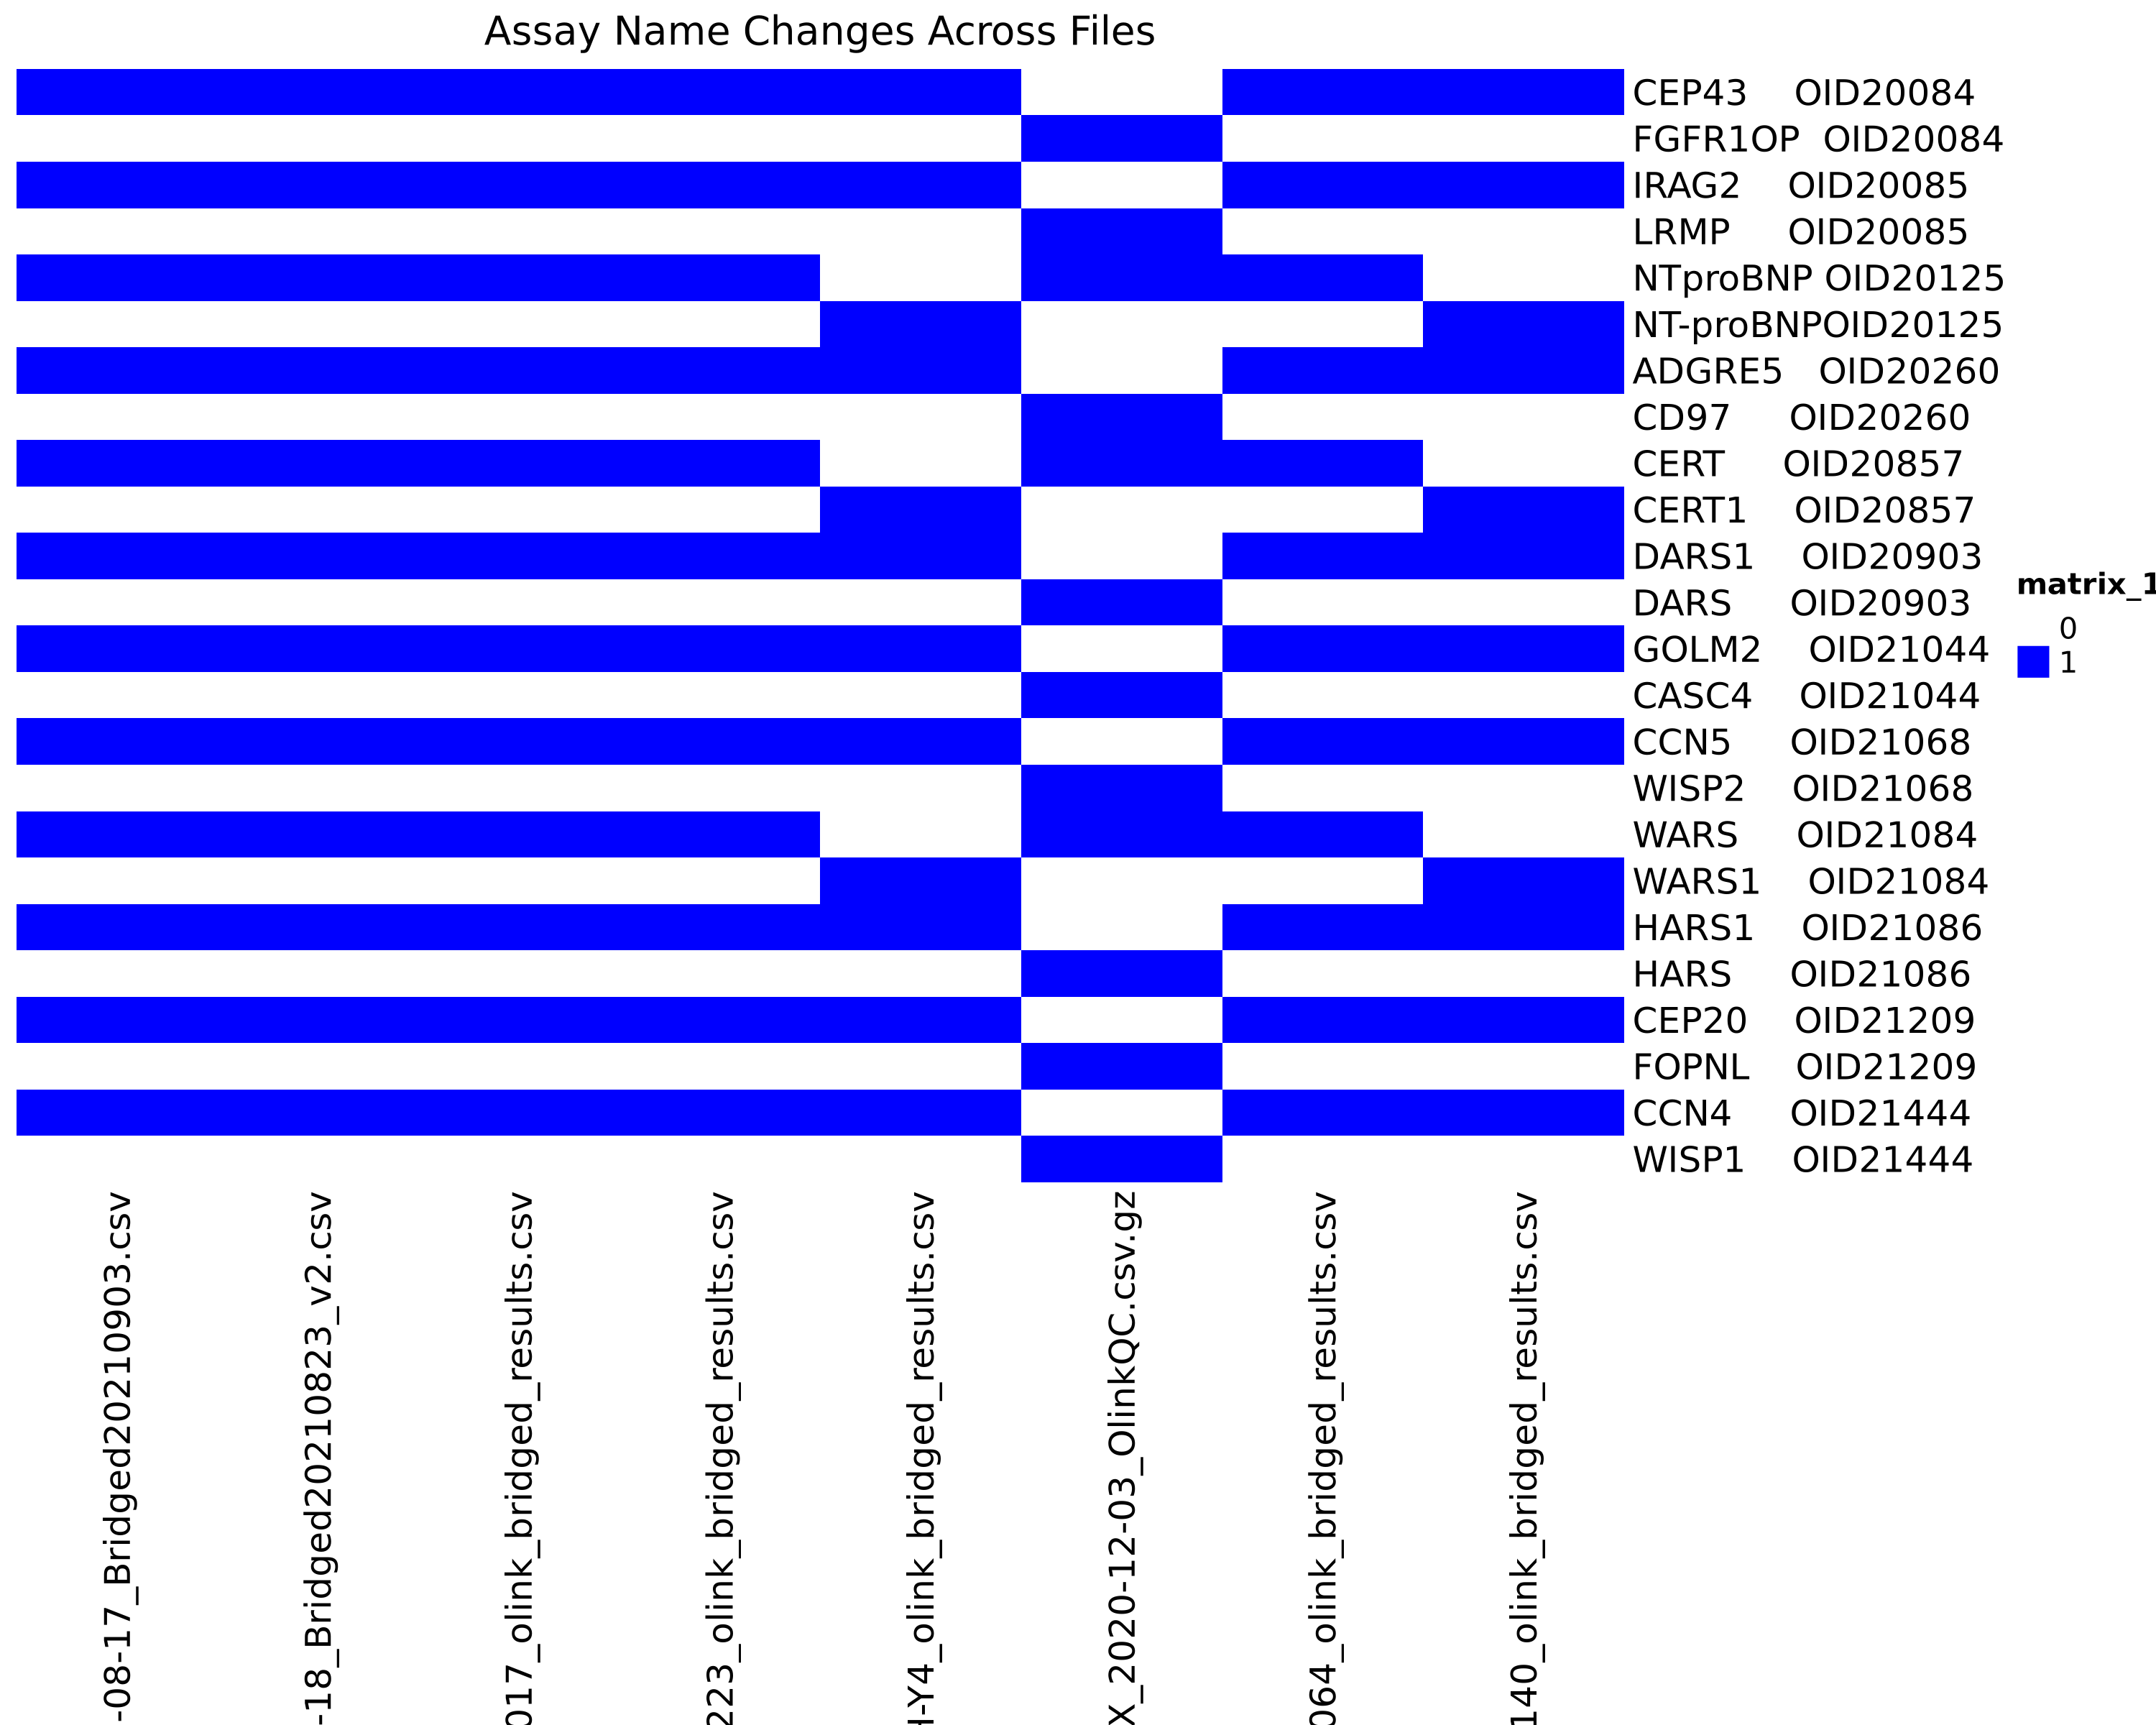

In [29]:
get_common_columns(data.olink.clipped.renamed)

data.olink.clipped.renamed %>% 
  stack_dfs(id="file") %>%
  check_one_to_one_mapping(reference_column = "OlinkID", target_column = "Assay", .id="file") %>%
  mutate(file = basename(file)) %>%
  mutate(ID = interaction(Assay, OlinkID)) %>% 
  mutate(value=1) %>% 
  arrange(OlinkID) %>%
  mutate(ID = justify_right_of_delimiter(ID, "\\.")) %>%
  value_presence_matrix("ID", "file", "value") %>%
  Heatmap(col = c("0" = "white", "1" = "blue"),
          show_row_names = TRUE, show_column_names = TRUE, 
          show_row_dend = FALSE, show_column_dend = FALSE,
          cluster_columns=F, cluster_rows=F,
          show_heatmap_legend = TRUE, column_title = "Assay Name Changes Across Files")

It can be seen that the assay names have been changed in two files, namely the qc (first) file and Y4_olink_bridged. All the other files follow a common naming cheme, which we will use. 
We will rename the assay names that are differing. 

OID20084, 1
OID20085, 2
OID20125, 3
OID20260, 4
OID20857, 5
OID20903, 6
OID21044, 7
OID21068, 8
OID21084, 9
OID21086, 10
OID21209, 11
OID21444, 12 

In [30]:
#function to rename valus in specified column

Assay.recode <- list(
  #the correct assignment for OlinkIDs
  CEP43 = "FGFR1OP",
  IRAG2 = "LRMP",
  NTproBNP = "NT-proBNP",
  ADGRE5 = "CD97",
  CERT = "CERT1",
  DARS1 = "DARS",
  GOLM2 = "CASC4",
  CCN5 = "WISP2",
  WARS = "WARS1", 
  HARS1 = "HARS",
  CEP20 = "FOPNL",
  CCN4 = "WISP1" # 12 proteins to standardize
)

data.olink.assay.oid.fixed <- map(data.olink.clipped.renamed, \(df) {
  df <- mutate(df, Assay = suppressWarnings(fct_recode(Assay, !!!Assay.recode))) #not all assays are present in all dfs which is known
  df
})



Check that there indeed is a one to one mapping of assay to OlinkID

In [31]:
# check that fixing of one-to-one mapping was successful
assay.to.olinkID.is.one.to.one <- data.olink.assay.oid.fixed %>% 
  stack_dfs(id="file") %>%
  has_one_to_one_mapping(reference_column = "OlinkID", target_column = "Assay", .id="file")

print(paste0("There is a one-to-one mapping of Assay to OlinkID: ", assay.to.olinkID.is.one.to.one))


INFO [2025-09-05 09:29:13] Found common column: SampleID
INFO [2025-09-05 09:29:13] Found common column: Index
INFO [2025-09-05 09:29:13] Found common column: OlinkID
INFO [2025-09-05 09:29:13] Found common column: UniProt
INFO [2025-09-05 09:29:13] Found common column: Assay
INFO [2025-09-05 09:29:13] Found common column: Panel
INFO [2025-09-05 09:29:13] Found common column: PlateID
INFO [2025-09-05 09:29:13] Found common column: Normalization
INFO [2025-09-05 09:29:13] Found common column: Assay_Warning
INFO [2025-09-05 09:29:13] Found common column: sampleKitGuid
INFO [2025-09-05 09:29:13] Found common column: UniqueAssay
INFO [2025-09-05 09:29:13] Found common column: N_Bridge
INFO [2025-09-05 09:29:13] Found common column: BatchOffset
INFO [2025-09-05 09:29:13] Found common column: submission_ref
INFO [2025-09-05 09:29:13] Found common column: NPX
INFO [2025-09-05 09:29:13] Found common column: LOD
INFO [2025-09-05 09:29:13] Found common column: SampleWarningBridge
INFO [2025-09-0

Certain assays are duplicated across plates in a batch. They will have the same assay name but different OlinkIDs. This means that there is a one to one mapping from OlinkID to assay, but these assays will point to different OlinkIDs depending on plate. This naming scheme is stable across the batches, as seen below. In the heatmap below, we can also see that one batch has assays not present in the other ones. This batch was larger than the other ones. This will be left as is for now. 

DEBUG [2025-09-05 09:29:14] y.axis: ID, x.axis: file, value: value.
INFO [2025-09-05 09:29:14] Found common column: SampleID
INFO [2025-09-05 09:29:14] Found common column: Index
INFO [2025-09-05 09:29:14] Found common column: OlinkID
INFO [2025-09-05 09:29:14] Found common column: UniProt
INFO [2025-09-05 09:29:14] Found common column: Assay
INFO [2025-09-05 09:29:14] Found common column: Panel
INFO [2025-09-05 09:29:14] Found common column: PlateID
INFO [2025-09-05 09:29:14] Found common column: Normalization
INFO [2025-09-05 09:29:14] Found common column: Assay_Warning
INFO [2025-09-05 09:29:14] Found common column: sampleKitGuid
INFO [2025-09-05 09:29:14] Found common column: UniqueAssay
INFO [2025-09-05 09:29:14] Found common column: N_Bridge
INFO [2025-09-05 09:29:14] Found common column: BatchOffset
INFO [2025-09-05 09:29:14] Found common column: submission_ref
INFO [2025-09-05 09:29:14] Found common column: NPX
INFO [2025-09-05 09:29:14] Found common column: LOD
INFO [2025-09-0

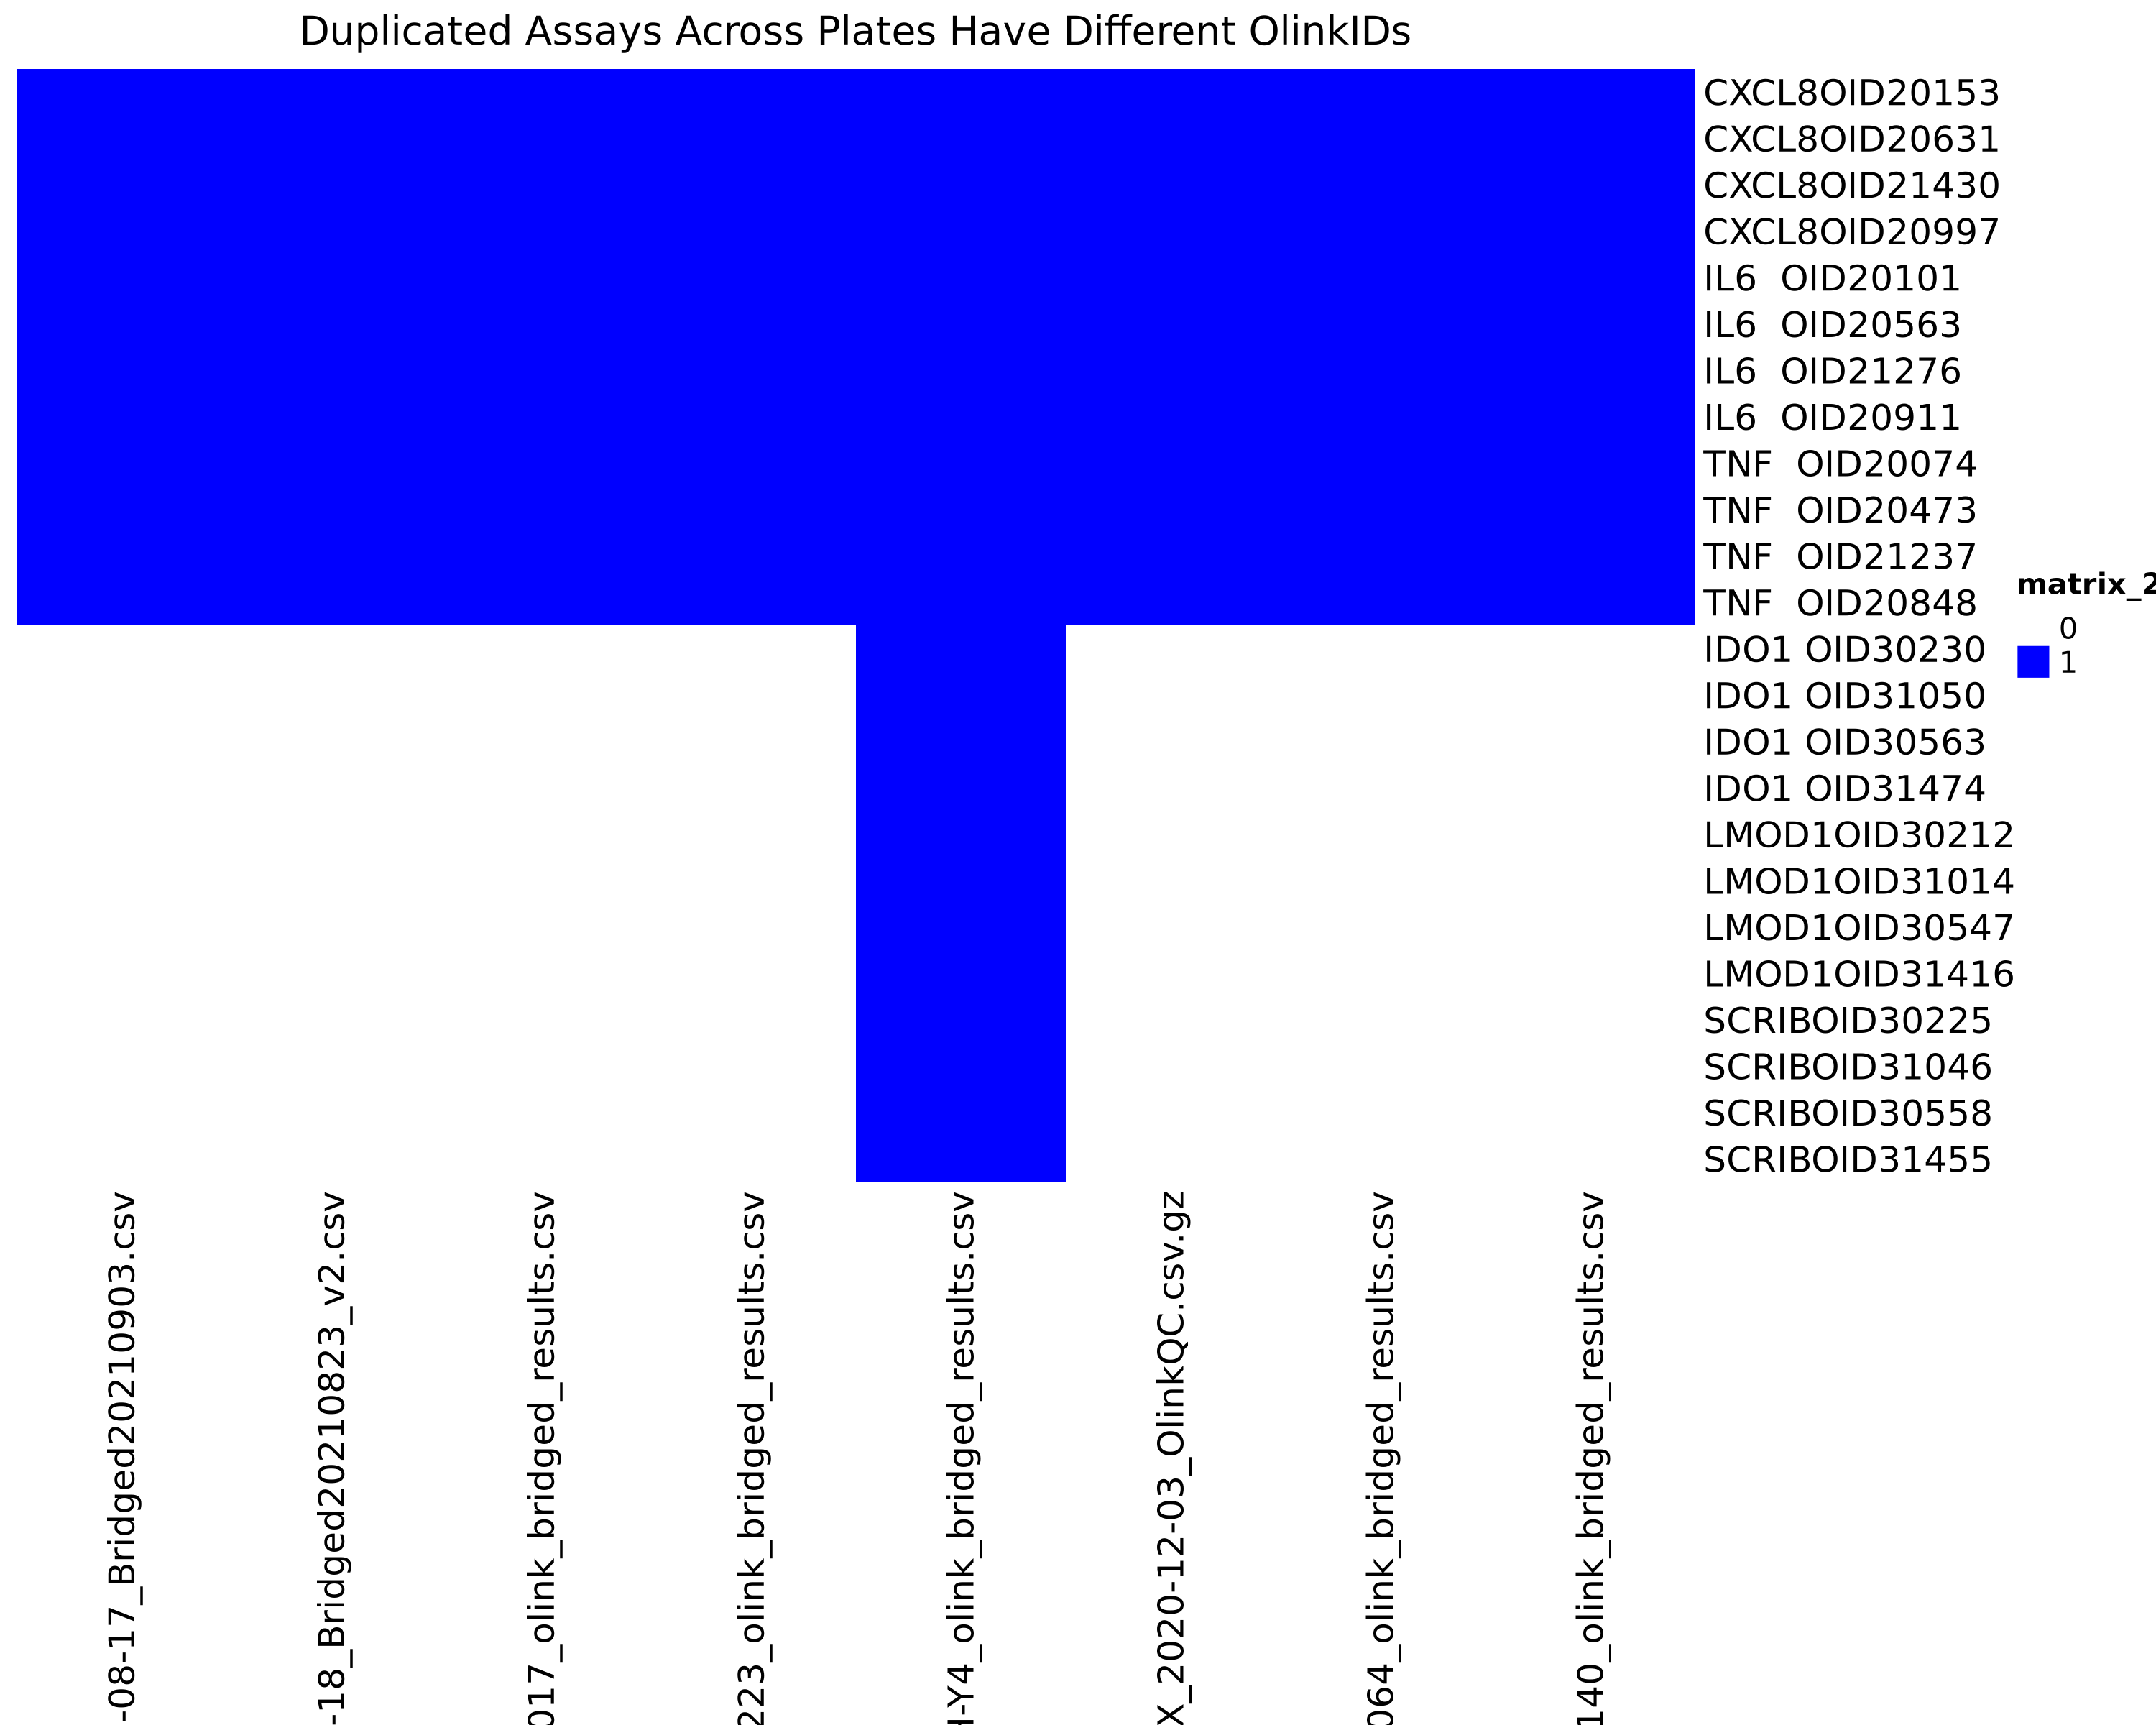

In [32]:
data.olink.assay.oid.fixed %>% 
  stack_dfs(id="file") %>%
  check_one_to_one_mapping(reference_column = "Assay", target_column = "OlinkID", .id="file") %>%
  mutate(file = basename(file)) %>%
  mutate(ID = interaction(Assay, OlinkID)) %>% 
  mutate(value=1) %>% 
  arrange(Assay) %>%
  mutate(ID = justify_right_of_delimiter(ID, "\\.")) %>%
  value_presence_matrix("ID", "file", "value") %>%
  Heatmap(col = c("0" = "white", "1" = "blue"),
          show_row_names = TRUE, show_column_names = TRUE, 
          show_row_dend = FALSE, show_column_dend = FALSE,
          cluster_columns=F, cluster_rows=F,
          show_heatmap_legend = TRUE, column_title = "Duplicated Assays Across Plates Have Different OlinkIDs")

We will double check that UniProt has a one-to-one mapping with Assay. A one-to-several exist between OlinkID and Assay for the proteins that are intentionally duplicated across plates in a batch, but only one Uniprot should map to one Assay.

In [33]:
data.olink.assay.oid.fixed %>% 
  stack_dfs(id="file") %>%
  has_one_to_one_mapping(reference_column = "UniProt", target_column = "Assay", .id="file")# %>%


INFO [2025-09-05 09:29:20] Found common column: SampleID
INFO [2025-09-05 09:29:20] Found common column: Index
INFO [2025-09-05 09:29:20] Found common column: OlinkID
INFO [2025-09-05 09:29:20] Found common column: UniProt
INFO [2025-09-05 09:29:20] Found common column: Assay
INFO [2025-09-05 09:29:20] Found common column: Panel
INFO [2025-09-05 09:29:20] Found common column: PlateID
INFO [2025-09-05 09:29:20] Found common column: Normalization
INFO [2025-09-05 09:29:20] Found common column: Assay_Warning
INFO [2025-09-05 09:29:20] Found common column: sampleKitGuid
INFO [2025-09-05 09:29:20] Found common column: UniqueAssay
INFO [2025-09-05 09:29:20] Found common column: N_Bridge
INFO [2025-09-05 09:29:20] Found common column: BatchOffset
INFO [2025-09-05 09:29:20] Found common column: submission_ref
INFO [2025-09-05 09:29:20] Found common column: NPX
INFO [2025-09-05 09:29:20] Found common column: LOD
INFO [2025-09-05 09:29:20] Found common column: SampleWarningBridge
INFO [2025-09-0

[1] TRUE

Double check that all rows are unique.

In [34]:
data.is.unique <- !any(duplicated(stack_dfs(data.olink.assay.oid.fixed)))
print(paste0("Data rows across all data sets are unique: ", data.is.unique))

INFO [2025-09-05 09:29:21] Found common column: SampleID
INFO [2025-09-05 09:29:21] Found common column: Index
INFO [2025-09-05 09:29:21] Found common column: OlinkID
INFO [2025-09-05 09:29:21] Found common column: UniProt
INFO [2025-09-05 09:29:21] Found common column: Assay
INFO [2025-09-05 09:29:21] Found common column: Panel
INFO [2025-09-05 09:29:21] Found common column: PlateID
INFO [2025-09-05 09:29:21] Found common column: Normalization
INFO [2025-09-05 09:29:21] Found common column: Assay_Warning
INFO [2025-09-05 09:29:21] Found common column: sampleKitGuid
INFO [2025-09-05 09:29:21] Found common column: UniqueAssay
INFO [2025-09-05 09:29:21] Found common column: N_Bridge
INFO [2025-09-05 09:29:21] Found common column: BatchOffset
INFO [2025-09-05 09:29:21] Found common column: submission_ref
INFO [2025-09-05 09:29:21] Found common column: NPX
INFO [2025-09-05 09:29:21] Found common column: LOD
INFO [2025-09-05 09:29:21] Found common column: SampleWarningBridge
INFO [2025-09-0

## Combine to one frame

Columns have been harmonised and assays and OlinkIDs checked. Now we will combine to one frame. 

In [35]:
data.olink.stacked <- stack_dfs(data.olink.assay.oid.fixed)

INFO [2025-09-05 09:30:04] Found common column: SampleID
INFO [2025-09-05 09:30:04] Found common column: Index
INFO [2025-09-05 09:30:04] Found common column: OlinkID
INFO [2025-09-05 09:30:04] Found common column: UniProt
INFO [2025-09-05 09:30:04] Found common column: Assay
INFO [2025-09-05 09:30:04] Found common column: Panel
INFO [2025-09-05 09:30:04] Found common column: PlateID
INFO [2025-09-05 09:30:04] Found common column: Normalization
INFO [2025-09-05 09:30:04] Found common column: Assay_Warning
INFO [2025-09-05 09:30:04] Found common column: sampleKitGuid
INFO [2025-09-05 09:30:04] Found common column: UniqueAssay
INFO [2025-09-05 09:30:04] Found common column: N_Bridge
INFO [2025-09-05 09:30:04] Found common column: BatchOffset
INFO [2025-09-05 09:30:04] Found common column: submission_ref
INFO [2025-09-05 09:30:04] Found common column: NPX
INFO [2025-09-05 09:30:04] Found common column: LOD
INFO [2025-09-05 09:30:04] Found common column: SampleWarningBridge
INFO [2025-09-0

The common columns in the combined data frame are the following

In [36]:
dim(data.olink.stacked)
head(data.olink.stacked,2)

[1] 4039727      20

SampleID,Index,OlinkID,UniProt,Assay,Panel,PlateID,Normalization,Assay_Warning,sampleKitGuid,UniqueAssay,N_Bridge,BatchOffset,submission_ref,NPX,LOD,SampleWarningBridge,BridgingDetails,filename,BatchID
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>
PL01542-01,1,OID20097,P13807,GYS1,Cardiometabolic,20211036_SS210188,Intensity,PASS,KT01542,GYS1,11,1.7528,20201752,3.0331,1.9277,NA,"Bridged to Dec 2020 data by median offset, warned samples excluded on per-assay basis",20211036_Skene_NPX_2021-08-17_Bridged20210903.csv,3
PL00837-01,2,OID20097,P13807,GYS1,Cardiometabolic,20211036_SS210188,Intensity,PASS,KT00837,GYS1,11,1.7528,20201752,6.1120,1.9277,NA,"Bridged to Dec 2020 data by median offset, warned samples excluded on per-assay basis",20211036_Skene_NPX_2021-08-17_Bridged20210903.csv,3


In [37]:
length(unique(data.olink.stacked$SampleID))

[1] 2486

## Indicate control samples in separate column 

Indicate control samples with a separate column TRUE for samples with 'CONTROL_SAMPLE_US_CS_AS' in their SampleID. 

In [38]:
data.olink.is.controls.bool <- grepl("^CONTROL_SAMPLE_US_CS_AS", data.olink.stacked[["SampleID"]], ignore.case = F)
data.olink.stacked %<>% mutate(is_control_sample = data.olink.is.controls.bool)

## Final Quality Checks
Use some common packages to really check that the data meets the assumptions we have.

We can see that OlinkID has a one to one relationship with UniqueAssay. UniqueAssay has the panel appended to its name to accomplish this. 

Uniprot and Assay has a one to one relationship. 

filename and BatchID has, as expected, a one to one relationship. 

In [39]:
#janitor::get_dupes(data.olink.samples, SampleID, Assay)
janitor::get_one_to_one(data.olink.stacked)

[[1]]
[1] "OlinkID"     "UniqueAssay"

[[2]]
[1] "UniProt" "Assay"  

[[3]]
[1] "filename" "BatchID"

## File Save
Save the combined data set in the project folder as "Normalised Unabridged Olink Plasma Samples FH1.csv"

In [40]:
str(data.olink.stacked)

tibble [4,039,727 × 21] (S3: tbl_df/tbl/data.frame)
 $ SampleID           : Factor w/ 2486 levels "PL-A18R-04","PL-C18R-06",..: 271 162 351 183 339 164 324 218 121 228 ...
 $ Index              : Factor w/ 90 levels "1","2","3","4",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ OlinkID            : Factor w/ 2944 levels "OID20049","OID20050",..: 48 48 48 48 48 48 48 48 48 48 ...
 $ UniProt            : Factor w/ 2926 levels "A1E959","A1L4H1",..: 400 400 400 400 400 400 400 400 400 400 ...
 $ Assay              : Factor w/ 2926 levels "AARSD1","ABHD14B",..: 630 630 630 630 630 630 630 630 630 630 ...
 $ Panel              : Factor w/ 8 levels "Cardiometabolic",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ PlateID            : Factor w/ 47 levels "20211036_SS210188",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Normalization      : Factor w/ 4 levels "Intensity","Plate control",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Assay_Warning      : Factor w/ 4 levels "PASS","WARN",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ sampleKitGuid      : Factor w/ 2229 leve

In [41]:
dim(data.olink.stacked)

[1] 4039727      21

In [42]:
# Local Save
file.name <- "Combined_Olink_plasma_samples_09-02-2025.csv"
data.output.path <- file.path("../Data", file.name)
write_excel_csv(data.olink.stacked, data.output.path)

In [43]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] OlinkQCReport_1.2.2   patchwork_1.2.0       data.table_1.17.8    
 [4] ComplexHeatmap_2.18.0 devtools_2.4.5        usethis_3.0.0        
 [7] OlinkAnalyze_4.3.1    logger_0.4.0          knitr_1.50           
[10] gtsummary_2.3.0       gtExtras_0.6.0        gt_1.0.0             
[13] car_3.1-2  

# HISE Checkpoint

In [44]:
project = 'FH_MM_Year4'
title <- paste("(Intermediate) Combined Bridged Plasma Olink", Sys.Date())
in_files <- hise.olink.ids
target_file <- data.output.path
target_file
title
in_files

[1] "../Data/Combined_Olink_plasma_samples_09-02-2025.csv"

[1] "(Intermediate) Combined Bridged Plasma Olink 2025-09-05"

[[1]]
[1] "00753770-4803-4947-a290-e7469c410067"

[[2]]
[1] "1a528317-bbf3-45b7-82c9-529577cf0b15"

[[3]]
[1] "55d5d20a-506a-459e-8315-7d66276fb8f9"

[[4]]
[1] "59f5f656-085f-4d0b-a240-68a9eb15e68e"

[[5]]
[1] "65103a13-52de-4f65-89fa-dd03296b4ecb"

[[6]]
[1] "7c2d668a-b851-4087-ba31-408de4ce889c"

[[7]]
[1] "b494cce8-1314-4f6e-9666-42f0c6e1c702"

[[8]]
[1] "748f218f-07c9-4303-a500-97b7621f920c"